In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#modul untuk ML
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import  DecisionTreeRegressor , plot_tree
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

#model
from sklearn import svm
from sklearn.linear_model import HuberRegressor,RANSACRegressor,TheilSenRegressor
from catboost import CatBoostRegressor,Pool

#imputer
from sklearn.impute import SimpleImputer, KNNImputer

#scaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

#encoder
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import BinaryEncoder

#binning
from sklearn.preprocessing import KBinsDiscretizer

#polynomial feature
from sklearn.preprocessing import PolynomialFeatures

#column transformer
from sklearn.compose import ColumnTransformer

#pipeline
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

#feature selection
from sklearn.feature_selection import SelectKBest, SelectPercentile, SelectFromModel, f_regression, f_classif, RFE, SequentialFeatureSelector

#resampling
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTEN, SMOTENC
from imblearn.under_sampling import RandomUnderSampler, CondensedNearestNeighbour, NeighbourhoodCleaningRule, NearMiss

#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import cross_validate, cross_val_score, train_test_split, KFold

#metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')
import shap

pd.set_option('display.max_colwidth',None)

___

# **Saudi Arabia Used Cars Syarah.com**

Kendaraan telah menjadi kebutuhan sehari-hari bagi banyak orang, baik untuk menunjang aktivitas pekerjaan, mobilitas keluarga, maupun kebutuhan bisnis. Seiring dengan meningkatnya kebutuhan mobilitas, permintaan terhadap kendaraan pribadi pun terus bertumbuh. Namun, tidak semua konsumen memiliki kemampuan finansial untuk membeli mobil baru, sehingga opsi membeli mobil bekas menjadi alternatif yang lebih terjangkau dan rasional secara ekonomi.

Pasar mobil bekas berkembang pesat karena menawarkan variasi harga yang lebih fleksibel, pilihan model yang beragam, serta depresiasi harga yang lebih stabil dibandingkan mobil baru. Meskipun demikian, dinamika pasar mobil bekas cenderung lebih kompleks karena harga kendaraan sangat dipengaruhi oleh berbagai faktor seperti usia kendaraan, kondisi penggunaan, merek, tipe, dan lokasi penjualan. Ketidakteraturan dalam penentuan harga sering kali menyebabkan ketimpangan antara nilai pasar yang wajar dan harga yang ditawarkan oleh penjual.

Syarah merupakan situs jual beli mobil bekas di Arab Saudi yang mempertemukan penjual dan pembeli kendaraan melalui platform digital. Syarah.com memberikan pelayanan maksimal pada situs dan aplikasi yang mereka buat seperti jenis dan merek mobil, variasi harga, dan juga lokasi kendaraan dapat diakses semua melalui situs dan aplikasi resmi. karena dalam operasionalnya, setiap penjual dapat mengunggah spesifikasi kendaraan seperti tipe mobil, merek, jenis transmisi, kelengkapan fitur, tahun produksi, kapasitas mesin, serta jarak tempuh. Informasi tersebut menjadi dasar utama dalam menentukan harga jual kendaraan. Maka dari itu pelanggan atau pembeli pada situs Syarah.com mendapatkan informasi lengkap dari seluruh kendaraan yang tersedia pada situs dan aplikasi.

___

## **Business Problem Statement**

Marketplace mobil bekas seperti Syarah pastinya memiliki permasalahan, salah satunya adalah proses penentuan harga kendaraan. Ketidaktepatan dalam menetapkan acuan harga berpotensi menyebabkan kendaraan terlalu mahal sehingga sulit terjual, atau terlalu murah sehingga merugikan penjual. Kondisi ini tidak hanya mempengaruhi efisiensi waktu terhadap pemilihan harga, tetapi juga berdampak pada dan performa bisnis marketplace secara keseluruhan. 

Dengan banyaknya faktor yang memengaruhi harga mobil bekas—seperti usia kendaraan, jarak tempuh, merek, tipe kendaraan, kapasitas mesin, serta wilayah penjualan—diperlukan pendekatan berbasis data yang mampu mengidentifikasi pola harga pasar secara objektif dan konsisten.

___

## **Stakeholders**

**Marketplace Team**

Spesifiknya adalah Marketplace Management & Marketplace Developers

___

## **Goals**

Membangun model machine learning yang mampu memprediksi harga mobil bekas berdasarkan karakteristik kendaraan, sehingga dapat digunakan sebagai sistem rekomendasi harga yang membantu seller menetapkan harga yang optimal dan kompetitif.

___

## **Analytical Approach**

Untuk menjawab permasalahan penentuan harga kendaraan di marketplace seperti Syarah, pendekatan yang digunakan dalam proyek ini adalah supervised machine learning dengan metode regresi, karena variabel target yang diprediksi berupa nilai numerik kontinu (Price).

Tahapan analisis dimulai dari eksplorasi data untuk memahami distribusi harga dan karakteristik kendaraan, kemudian dilanjutkan dengan proses data preprocessing seperti encoding pada variabel kategorikal, scaling pada variabel numerik, serta feature engineering. Pada tahap feature engineering, ditambahkan variabel Car_Age untuk merepresentasikan usia kendaraan dan Mileage_Per_Year untuk menggambarkan intensitas penggunaan kendaraan secara lebih representatif dibandingkan hanya melihat total mileage.

Selanjutnya dilakukan proses pemodelan dengan membandingkan beberapa algoritma regresi untuk menemukan model dengan performa terbaik. Setelah model terbaik diperoleh, dilakukan hyperparameter tuning guna mengoptimalkan performa serta mengurangi risiko overfitting. Evaluasi akhir dilakukan pada data testing untuk memastikan model memiliki kemampuan generalisasi yang baik terhadap data baru.

___

## **Evaluation Metrics**

Tujuan utama proyek ini adalah memprediksi harga mobil bekas secara akurat dan stabil, Evaluasi model dilakukan menggunakan beberapa metrik regresi berikut:

1. Root Mean Squared Error (RMSE)
RMSE digunakan untuk mengukur rata-rata besar kesalahan prediksi dalam satuan harga yang sama dengan target. Metrik ini sensitif terhadap error besar, sehingga cocok digunakan dalam konteks pricing, di mana kesalahan prediksi yang terlalu jauh dari harga pasar dapat berdampak signifikan terhadap keputusan bisnis.

2. Mean Absolute Error (MAE)
MAE mengukur rata-rata selisih absolut antara harga aktual dan harga prediksi. Metrik ini memberikan gambaran yang lebih mudah diinterpretasikan karena menunjukkan rata-rata kesalahan harga yang terjadi tanpa memperbesar pengaruh outlier.

3. Mean Absolute Percentage Error (MAPE)
MAPE digunakan untuk memahami besar kesalahan dalam bentuk persentase terhadap harga aktual. Metrik ini membantu stakeholder memahami seberapa besar deviasi harga model dibandingkan nilai sebenarnya dalam konteks persentase, yang lebih intuitif secara bisnis.

Selain itu, dilakukan evaluasi terhadap gap antara performa training dan testing untuk memastikan model tidak mengalami overfitting. Model yang baik diharapkan memiliki error yang rendah sekaligus stabil pada data baru, sehingga dapat diandalkan saat diimplementasikan dalam sistem produksi.

___

## **Data Understanding**

- Dataset merupakan data listing mobil bekas yang dijual pada lokasi asal Saudi Arabia.
- Setiap baris data merepresentasikan informasi terkait kendaraan yang dijual.

**Attributes Information**

| **Attribute** | **Data Type** | **Description** |
| --- | --- | --- |
| Type | Object | Type of used car |
| Region | Object | Region of used car |
| Make | Object | The company name |
| Gear_Type | Object | Gear type size of used car |
| Origin| Object | Origin of used car |
| Options| Object | Options of used car |
| Year | Integer | Manufacturing year |
| Engine_Size | Float | The engine size of used car |
| Mileage | Integer | Mileage |
| Negotiable | Object | Negotiable in dollars |
| Price | Integer | Amount of used car |

<br>

___

## **Data**

In [71]:
df=pd.read_csv(r'D:\Purwadika\Modul_3_(Machine Learning)\Capstone\Dataset\data_saudi_used_cars.csv')
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,False,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,False,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,False,154000


In [72]:
df.sort_values(by='Price',ascending=1)

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
2795,Land Cruiser,Qassim,Toyota,Automatic,Saudi,Full,2014,4.6,495000,True,0
2796,H1,Riyadh,Hyundai,Automatic,Other,Semi Full,2015,2.7,112000,True,0
2803,Optima,Riyadh,Kia,Automatic,Saudi,Standard,2018,2.0,11000,True,0
2804,A8,Riyadh,Audi,Automatic,Saudi,Full,2014,3.0,175,True,0
...,...,...,...,...,...,...,...,...,...,...,...
4653,Range Rover,Riyadh,Land Rover,Automatic,Other,Full,2019,5.0,4200,False,599000
2120,Ghost,Dammam,Rolls-Royce,Automatic,Saudi,Full,2016,6.0,40000,False,620000
4273,S,Dammam,Mercedes,Automatic,Gulf Arabic,Full,2021,3.0,2500,False,748000
4684,G,Riyadh,Mercedes,Automatic,Other,Full,2019,4.0,39000,False,800000


In [73]:
df.duplicated().sum()

np.int64(4)

In [74]:
df = df.drop_duplicates()

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5620 entries, 0 to 5623
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         5620 non-null   object 
 1   Region       5620 non-null   object 
 2   Make         5620 non-null   object 
 3   Gear_Type    5620 non-null   object 
 4   Origin       5620 non-null   object 
 5   Options      5620 non-null   object 
 6   Year         5620 non-null   int64  
 7   Engine_Size  5620 non-null   float64
 8   Mileage      5620 non-null   int64  
 9   Negotiable   5620 non-null   bool   
 10  Price        5620 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 488.5+ KB


In [76]:
df.columns

Index(['Type', 'Region', 'Make', 'Gear_Type', 'Origin', 'Options', 'Year',
       'Engine_Size', 'Mileage', 'Negotiable', 'Price'],
      dtype='object')

In [77]:
df.describe()

,Year,Engine_Size,Mileage,Price
count,5620.000000,5620.000000,5.620000e+03,5620.000000
mean,2014.100356,3.296299,1.509222e+05,53086.404448
std,5.793003,1.515253,3.829633e+05,70175.153207
min,1963.000000,1.000000,1.000000e+02,0.000000
25%,2012.000000,2.000000,3.800000e+04,0.000000
50%,2016.000000,3.000000,1.030000e+05,36500.000000
75%,2018.000000,4.500000,1.960000e+05,73000.000000
max,2022.000000,9.000000,2.000000e+07,850000.000000


In [78]:
df.corr(numeric_only=True)

,Year,Engine_Size,Mileage,Negotiable,Price
Year,1.000000,-0.245219,-0.209781,-0.189033,0.293690
Engine_Size,-0.245219,1.000000,0.049467,0.111093,0.151876
Mileage,-0.209781,0.049467,1.000000,0.031563,-0.095323
Negotiable,-0.189033,0.111093,0.031563,1.000000,-0.518269
Price,0.293690,0.151876,-0.095323,-0.518269,1.000000


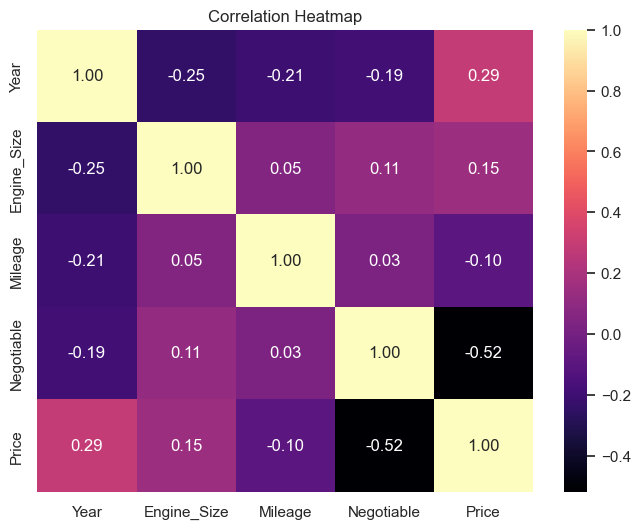

In [79]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='magma', 
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

___

## **EDA**

In [80]:
unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': [df[col].unique() for col in df.columns]
})

unique_summary

,Column,Unique_Count
0,Type,"[Corolla, Yukon, Range Rover, Optima, FJ, CX3, Cayenne S, Sonata, Avalon, LS, C300, Land Cruiser, Hilux, Tucson, Caprice, Sunny, Pajero, Azera, Focus, 5, Spark, Camry, Pathfinder, Accent, ML, Tahoe, Yaris, Suburban, A, Altima, Traverse, Expedition, Senta fe, Liberty, 3, X, Elantra, Land Cruiser Pickup, VTC, Malibu, The 5, A8, Patrol, Grand Cherokee, SL, Previa, SEL, Aveo, MKZ, Victoria, Datsun, Flex, GLC, ES, Edge, 6, Escalade, Innova, Navara, H1, G80, Carnival, Symbol, Camaro, Accord, Avanza, Land Cruiser 70, Taurus, C5700, Impala, Optra, S, Other, Cerato, Furniture, Murano, Explorer, LX, Pick up, Charger, H6, BT-50, Hiace, Ranger, Fusion, Rav4, Ciocca, CX9, Kona, Sentra, Sierra, Durango, CT-S, Sylvian Bus, Navigator, Opirus, Marquis, The 7, FX, Creta, ...]"
1,Region,"[Abha, Riyadh, Hafar Al-Batin, Aseer, Makkah, Dammam, Yanbu, Al-Baha, Jeddah, Hail, Khobar, Al-Ahsa, Jazan, Al-Medina, Al-Namas, Tabouk, Taef, Qassim, Arar, Jubail, Sabya, Al-Jouf, Najran, Wadi Dawasir, Qurayyat, Sakaka, Besha]"
2,Make,"[Toyota, GMC, Land Rover, Kia, Mazda, Porsche, Hyundai, Lexus, Chrysler, Chevrolet, Nissan, Mitsubishi, Ford, MG, Mercedes, Jeep, BMW, Audi, Lincoln, Cadillac, Genesis, Renault, Honda, Suzuki, Zhengzhou, Dodge, HAVAL, INFINITI, Isuzu, Changan, Aston Martin, Mercury, Great Wall, Other, Rolls-Royce, MINI, Volkswagen, BYD, Geely, Victory Auto, Classic, Jaguar, Daihatsu, Maserati, Hummer, GAC, Lifan, Bentley, Chery, Peugeot, Foton, Škoda, Fiat, Iveco, SsangYong, FAW, Tata, Ferrari]"
3,Gear_Type,"[Manual, Automatic]"
4,Origin,"[Saudi, Gulf Arabic, Other, Unknown]"
5,Options,"[Standard, Full, Semi Full]"
6,Year,"[2013, 2014, 2015, 2020, 2019, 2012, 2016, 1998, 2011, 2008, 1982, 1985, 2018, 1983, 2021, 2017, 2002, 2010, 2009, 2004, 2001, 1986, 2007, 1999, 2005, 1977, 1991, 2003, 1995, 2006, 1997, 1993, 1996, 2000, 1990, 1965, 1980, 1987, 1994, 1988, 1989, 1978, 2022, 1975, 1964, 1984, 1979, 1992, 1963, 1981]"
7,Engine_Size,"[1.4, 8.0, 5.0, 2.4, 4.0, 2.0, 4.8, 3.5, 4.6, 5.7, 2.7, 1.0, 3.0, 1.6, 1.5, 3.3, 6.2, 2.5, 5.3, 3.6, 5.4, 1.7, 3.7, 9.0, 4.7, 4.5, 3.8, 5.5, 2.6, 1.8, 1.2, 6.0, 6.9, 3.2, 5.9, 2.2, 5.6, 1.1, 2.9, 4.1, 1.3, 4.4, 2.8, 3.4, 8.8, 6.1, 7.0, 1.9, 7.5, 4.3, 6.5, 3.1, 6.3, 6.4, 5.8, 8.5, 2.3, 6.6, 7.2, 4.2, 5.1, 7.4, 5.2, 2.1, 6.7, 7.8, 3.9, 8.7, 4.9, 6.8, 8.9]"
8,Mileage,"[421000, 80000, 140000, 220000, 49000, 25000, 189000, 155, 110864, 300, 200, 79000, 299000, 17000, 209, 340000, 30000, 71000, 85000, 500000, 290, 74715, 250, 284000, 98000, 3400, 108, 350000, 550000, 204000, 139240, 296, 105920, 187000, 10000, 18500, 292000, 280000, 270000, 345500, 110000, 247000, 55800, 92000, 27000, 600000, 307801, 62000, 38000, 89000, 137000, 422000, 208000, 11000, 245000, 500, 150000, 81000, 156000, 42000, 228000, 24000, 266000, 98100, 182000, 210800, 88000, 214000, 82808, 4000, 417970, 70000, 115, 270373, 91440, 45000, 96000, 50100, 35449, 180, 66200, 100, 349000, 168000, 105000, 130000, 212000, 139740, 256, 280, 73000, 240000, 866, 216, 183000, 148000, 4358765, 188257, 117000, 160000, ...]"
9,Negotiable,"[True, False]"


In [81]:
# Ganti Origin 'Unknown' menjadi 'Other'
df['Origin'] = df['Origin'].replace('Unknown','Other')

In [82]:
# Drop kolom 'Negotiable' karena kolom tersebut dinilai kurang representative terhadap data
df = df.drop(['Negotiable'], axis=1)

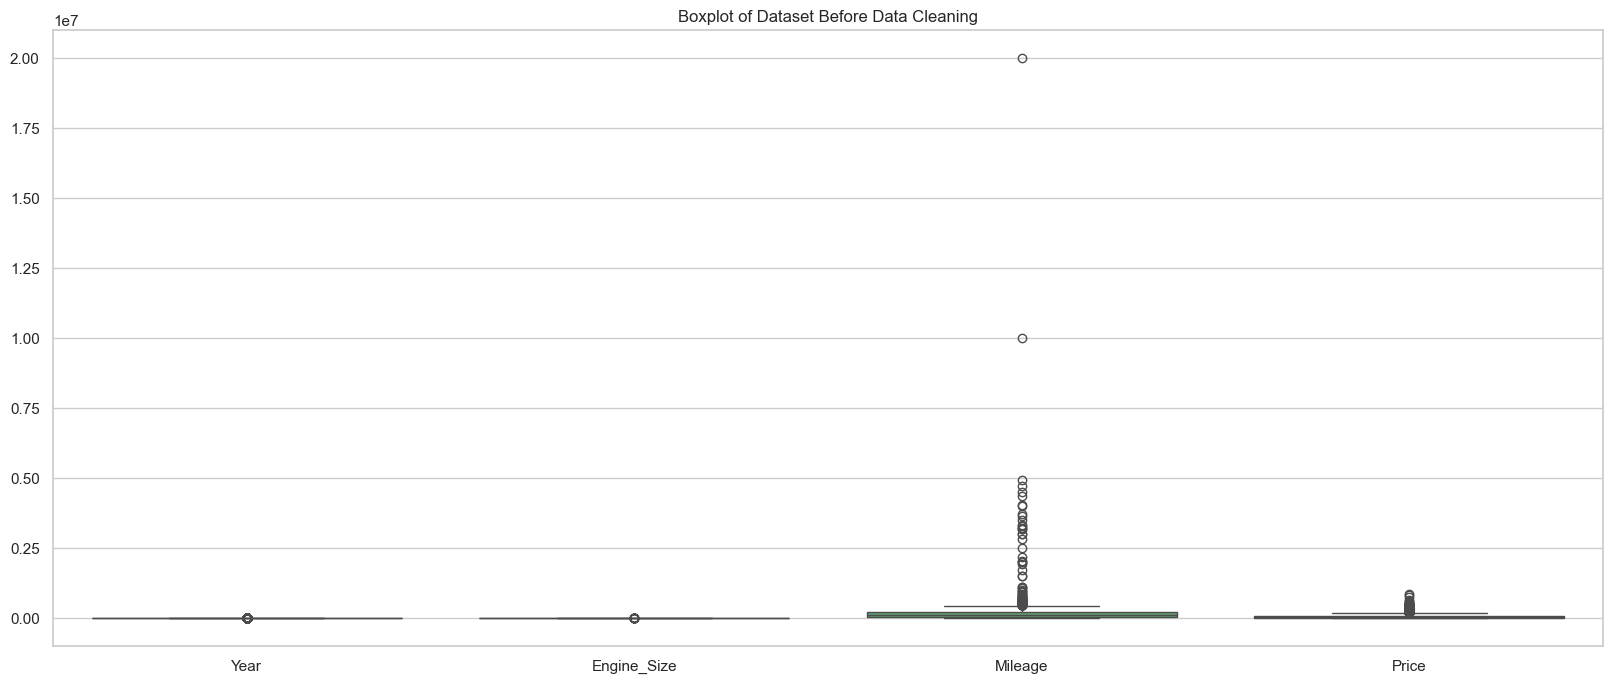

In [83]:
plt.figure(figsize=(20,8))
sns.boxplot(data=df)
plt.title('Boxplot of Dataset Before Data Cleaning')
plt.show()

In [84]:
# Function for checking outliers
def outlier_data(df):
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    limit = iqr*1.5
    print(f'IQR: {iqr}')

    lower_bound = q1 - limit
    upper_bound = q3 + limit
    print(f'lower_bound: {lower_bound}')
    print(f'upper_bound: {upper_bound}')  

In [85]:
for col in df.describe().columns:
    print(f"Kolom: {col}")
    outlier_data(df[col])
    print("----------------")

Kolom: Year
IQR: 6.0
lower_bound: 2003.0
upper_bound: 2027.0
----------------
Kolom: Engine_Size
IQR: 2.5
lower_bound: -1.75
upper_bound: 8.25
----------------
Kolom: Mileage
IQR: 158000.0
lower_bound: -199000.0
upper_bound: 433000.0
----------------
Kolom: Price
IQR: 73000.0
lower_bound: -109500.0
upper_bound: 182500.0
----------------


___

### Mengetahui distribusi kolom `Year`

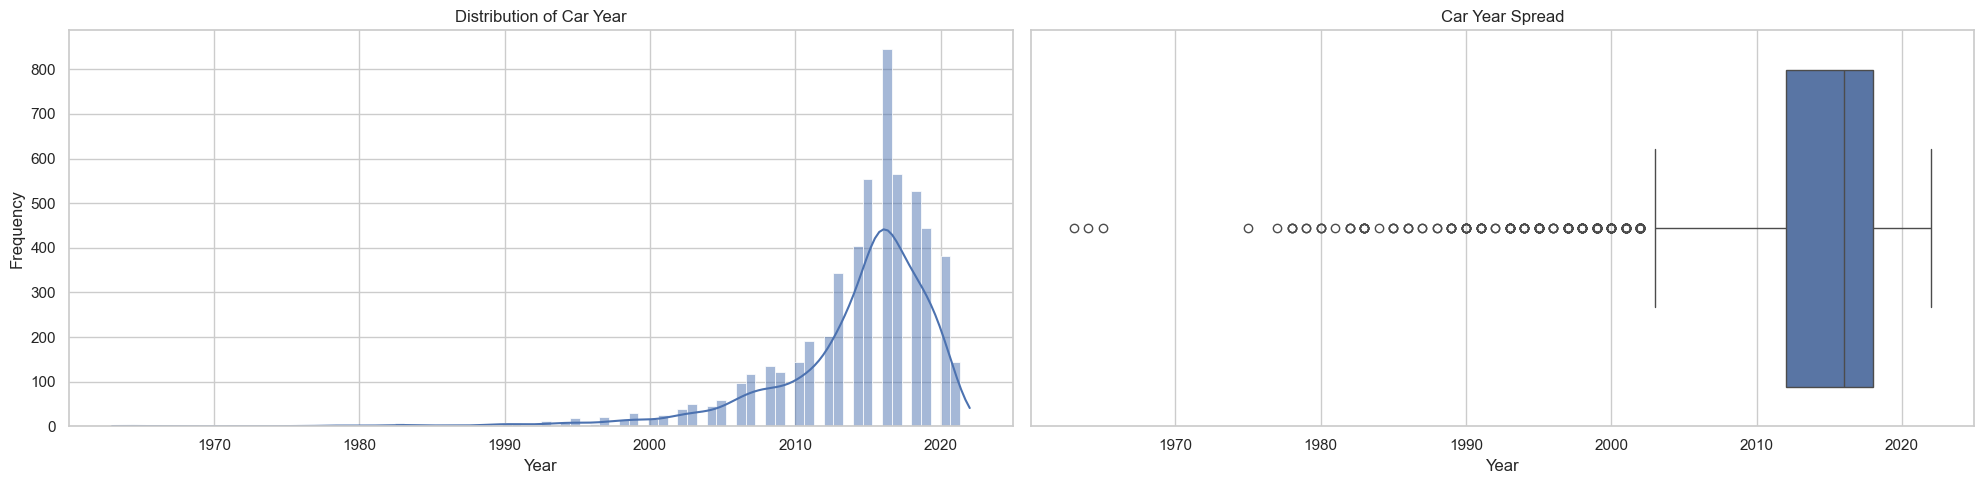

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Year'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Year'], ax=axes[1])
axes[1].set_title('Car Year Spread')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

In [87]:
df['Year'].describe()

count    5620.000000
mean     2014.100356
std         5.793003
min      1963.000000
25%      2012.000000
50%      2016.000000
75%      2018.000000
max      2022.000000
Name: Year, dtype: float64

In [88]:
df.sort_values(by='Year', ascending=True)[
    ['Make','Type','Engine_Size','Price','Year']
].head(30)

,Make,Type,Engine_Size,Price,Year
5012,Ford,Other,1.0,22000,1963
2262,Chevrolet,Impala,1.2,75000,1964
617,Ford,Thunderbird,8.0,0,1965
1871,Mercedes,POS24,8.0,0,1975
104,GMC,C5700,1.5,0,1977
1363,Chrysler,New Yorker,6.6,0,1978
3238,Nissan,Patrol,4.0,28000,1978
3082,Toyota,Land Cruiser 70,4.0,18000,1978
5147,Ford,Bronco,4.9,0,1979
3188,GMC,Sierra,5.3,0,1979


Ditemukan sejumlah kecil kendaraan dengan tahun produksi sangat lama (Tahun 1963) yang berada jauh di luar distribusi utama yaitu pada tahun 2014–2021. Hal ini mungkin saja terjadi pada pasar jual beli mobil bekas, karena mobil pada tahun tua atau dibawah tahun 2000 bisa dikategorikan sebagai **Mobil Antik**. Namun secara domain knowledge hal ini jarang terjadi karena mobil-mobil antik atau mobil yang memiliki nilai barang koleksi dijual melalui platform lain dan sangat jarang masuk ke situs jual beli mobil bekas karena peminatnya sudah pasti yang memiliki hobi mengoleksi mobil antik.

Jadi mobil mobil yang di produksi dibawah tahun 2000 akan dianggap sebagai outlier dan berpotensi memengaruhi model secara tidak proporsional, sehingga dilakukan penyaringan berdasarkan batas tahun produksi yang lebih representatif terhadap pasar mobil bekas modern. Observasi tersebut dianggap sebagai outlier dan berpotensi memengaruhi model, sehingga dilakukan penyaringan berdasarkan batas tahun produksi yang lebih representatif terhadap pasar mobil bekas modern.

In [89]:
df = df[df['Year'] >= 2000]
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0
...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000


#### Mengetahui distribusi kolom `Year` setelah handling Outlier

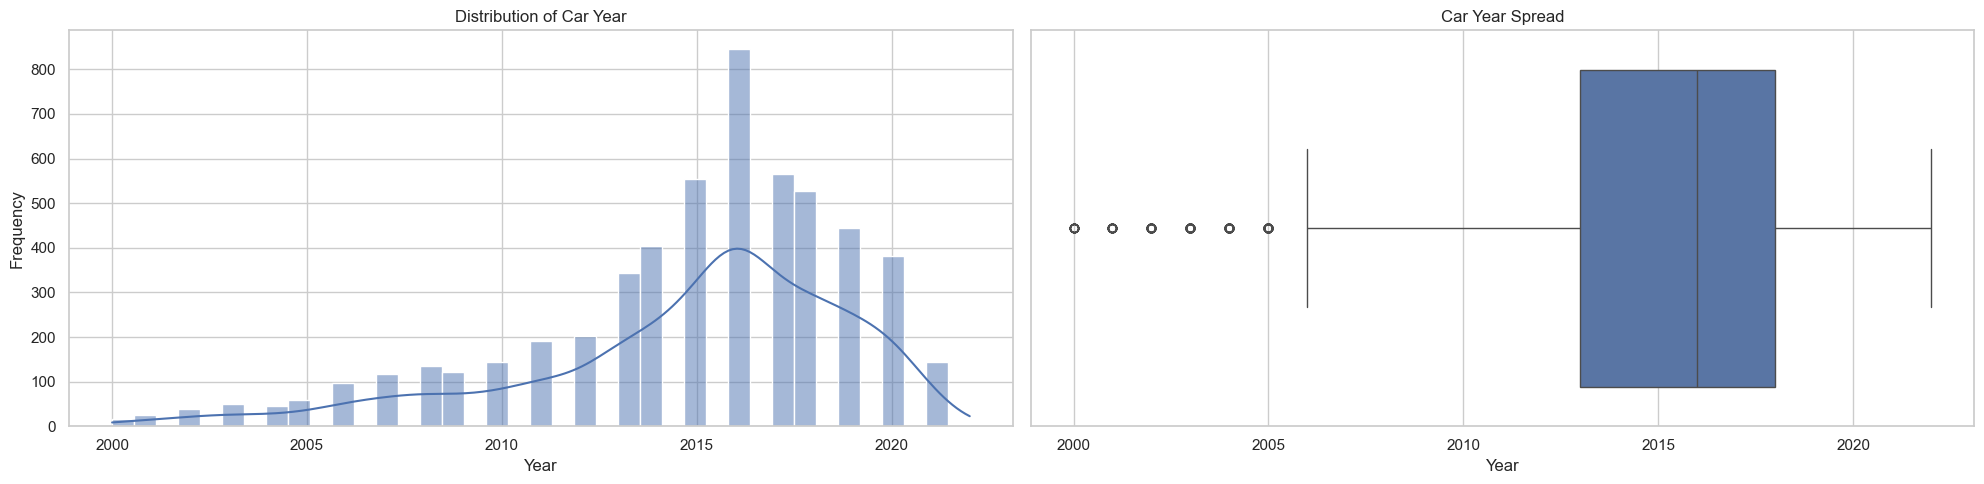

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Year'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Year'], ax=axes[1])
axes[1].set_title('Car Year Spread')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

___

### Feature Engineering : `Car Age`

Feature Engineering : Kolom tahun produksi ditransformasikan menjadi usia kendaraan (Car_Age) karena harga mobil lebih dipengaruhi oleh tingkat depresiasi yang sejalan dengan pertambahan usia, bukan oleh angka tahun absolut. Transformasi ini meningkatkan relevansi fitur terhadap target serta mempermudah model dalam menangkap pola hubungan antara usia kendaraan dan harga.

In [91]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0,13
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000,12
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000,11
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,11
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0,6
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000,8
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0,6
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000,10
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000,10


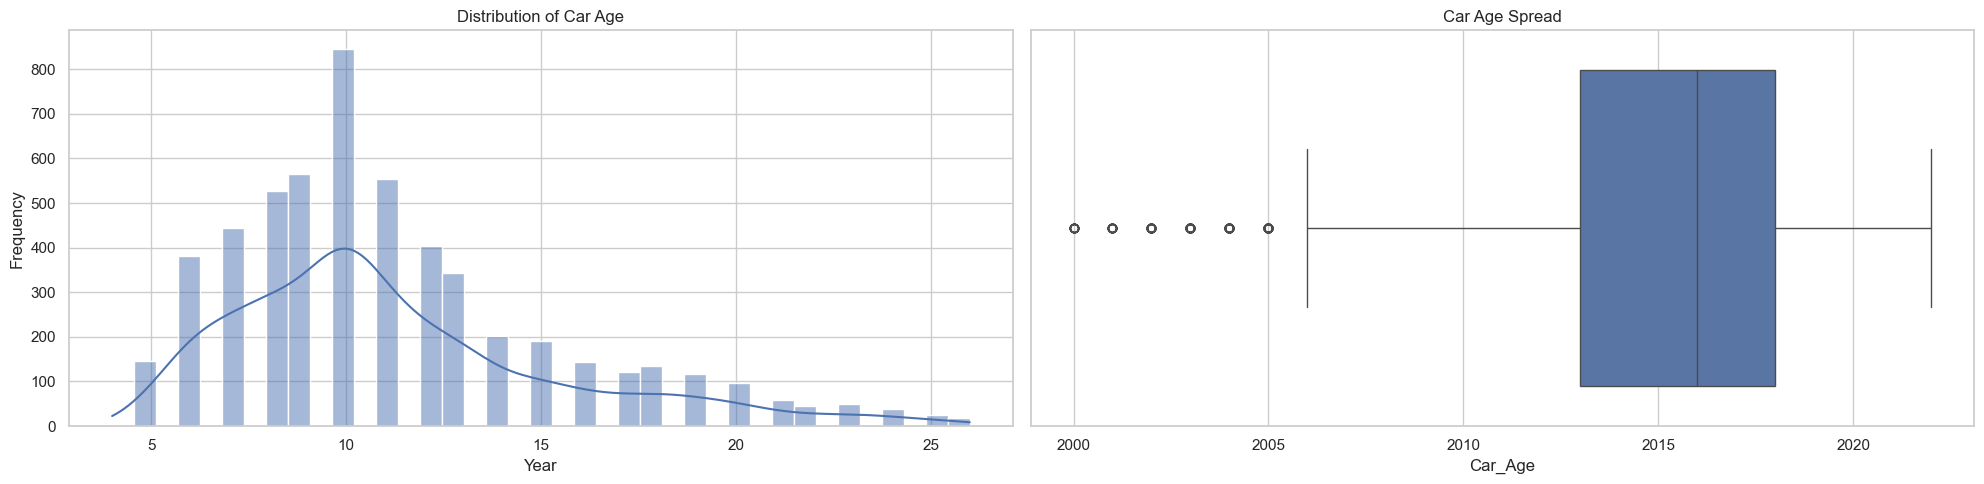

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Car_Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Age')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Year'], ax=axes[1])
axes[1].set_title('Car Age Spread')
axes[1].set_xlabel('Car_Age')

plt.tight_layout()
plt.show()

___

### Mengetahui distribusi kolom `Engine Size`

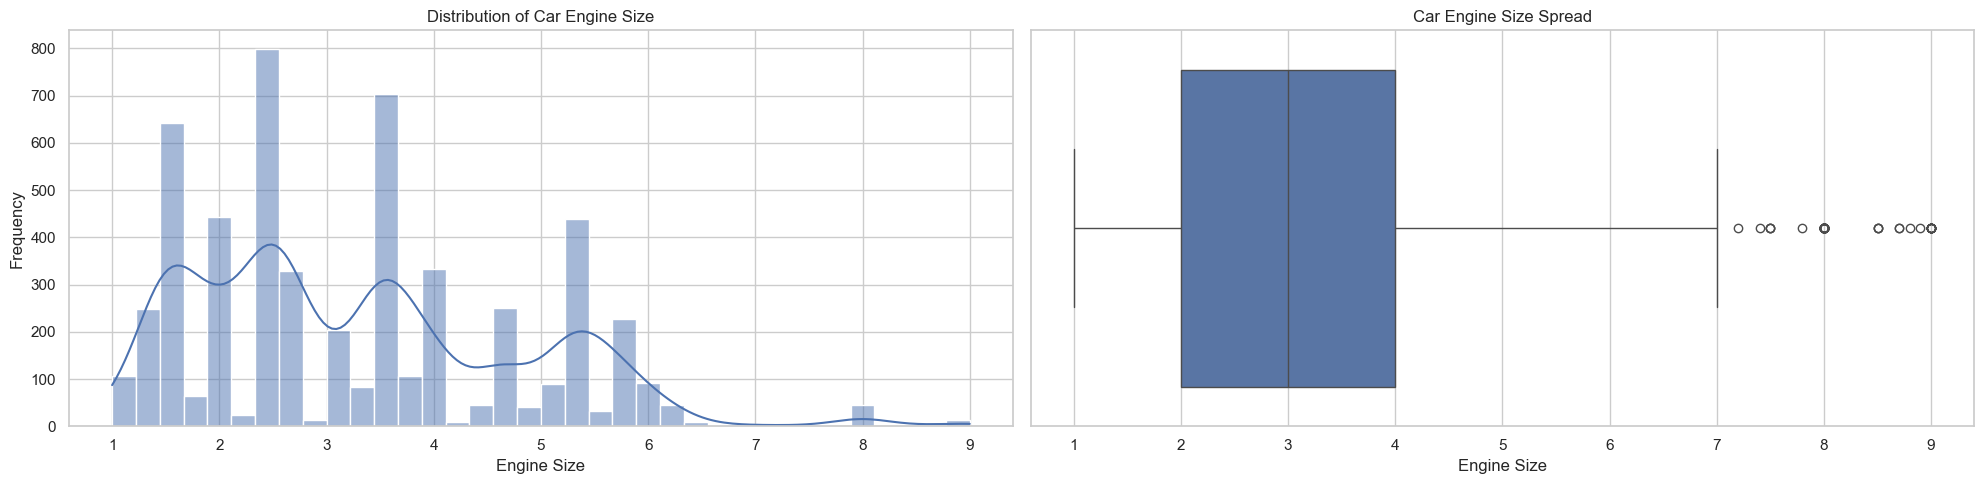

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Engine_Size'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Engine Size')
axes[0].set_xlabel('Engine Size')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Engine_Size'], ax=axes[1])
axes[1].set_title('Car Engine Size Spread')
axes[1].set_xlabel('Engine Size')

plt.tight_layout()
plt.show()

In [94]:
df.sort_values(by='Engine_Size', ascending=False)[
    ['Make','Type','Engine_Size','Price','Year']
].head(30)

,Make,Type,Engine_Size,Price,Year
1547,Ford,Marquis,9.0,17000,2008
421,Toyota,Land Cruiser,9.0,0,2014
2019,Ford,Flex,9.0,0,2011
2217,Toyota,Camry,9.0,36000,2014
59,Toyota,Camry,9.0,15000,2001
650,Mercedes,E,9.0,155000,2017
3525,Toyota,FJ,9.0,75000,2014
5251,GMC,Sierra,9.0,178000,2021
3546,Toyota,Land Cruiser,9.0,0,2009
5101,GMC,Yukon,9.0,0,2010


#### Pada kolom `Engine_Size` terdapat kendaraan penumpang umumnya memiliki kapasitas mesin di bawah 7.0 liter. Berdasarkan domain knowledge pada industri otomotif, Nilai kapasitas mesin di atas ambang tersebut dianggap tidak realistis untuk mayoritas kendaraan dalam dataset dan berpotensi merupakan kesalahan input data. Oleh karena itu, observasi dengan nilai engine size di atas 7.0 liter dihapus guna mencegah bias pada proses pemodelan.

In [95]:
df = df[df['Engine_Size'] <= 7]
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0,13
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000,11
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,11
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0,6
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000,7
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000,8
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0,6
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000,10
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000,10


#### Mengetahui distribusi kolom `Engine Size` setelah handling Outlier

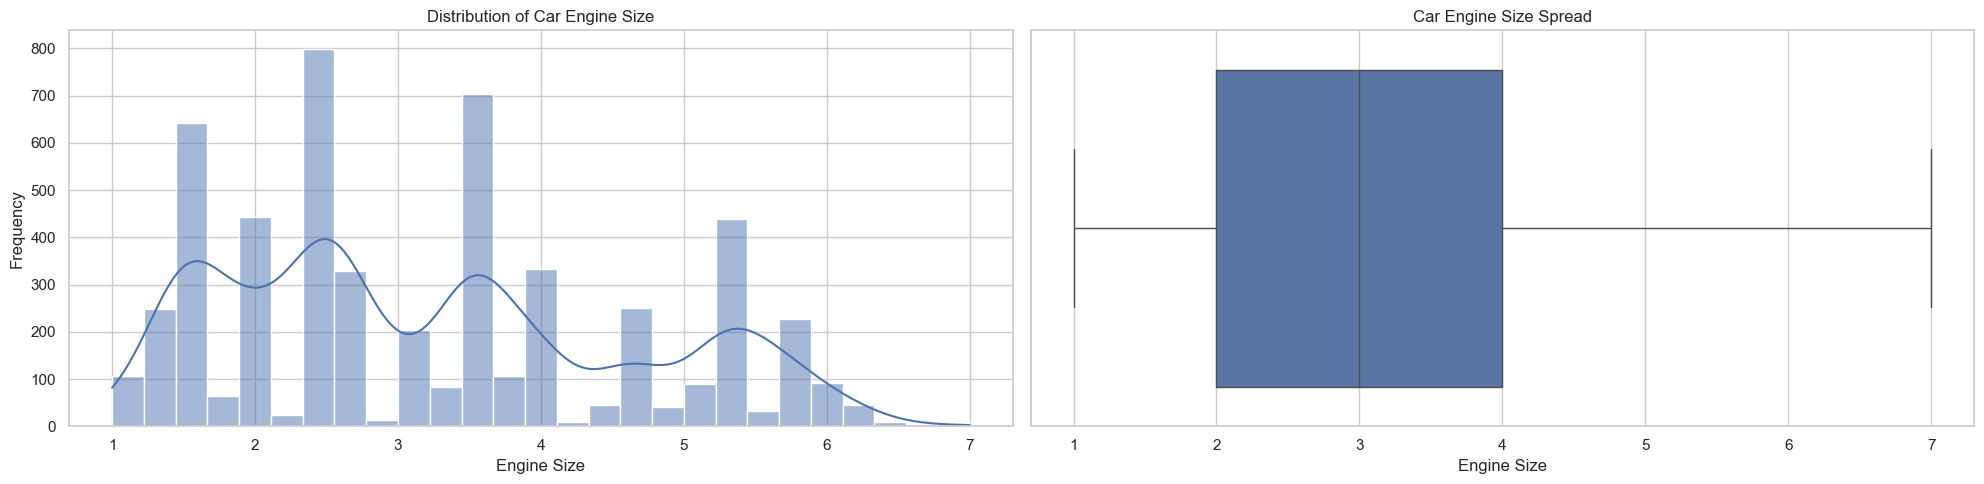

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Engine_Size'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Engine Size')
axes[0].set_xlabel('Engine Size')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Engine_Size'], ax=axes[1])
axes[1].set_title('Car Engine Size Spread')
axes[1].set_xlabel('Engine Size')

plt.tight_layout()
plt.show()

___

### Mengetahui distribusi kolom `Mileage`

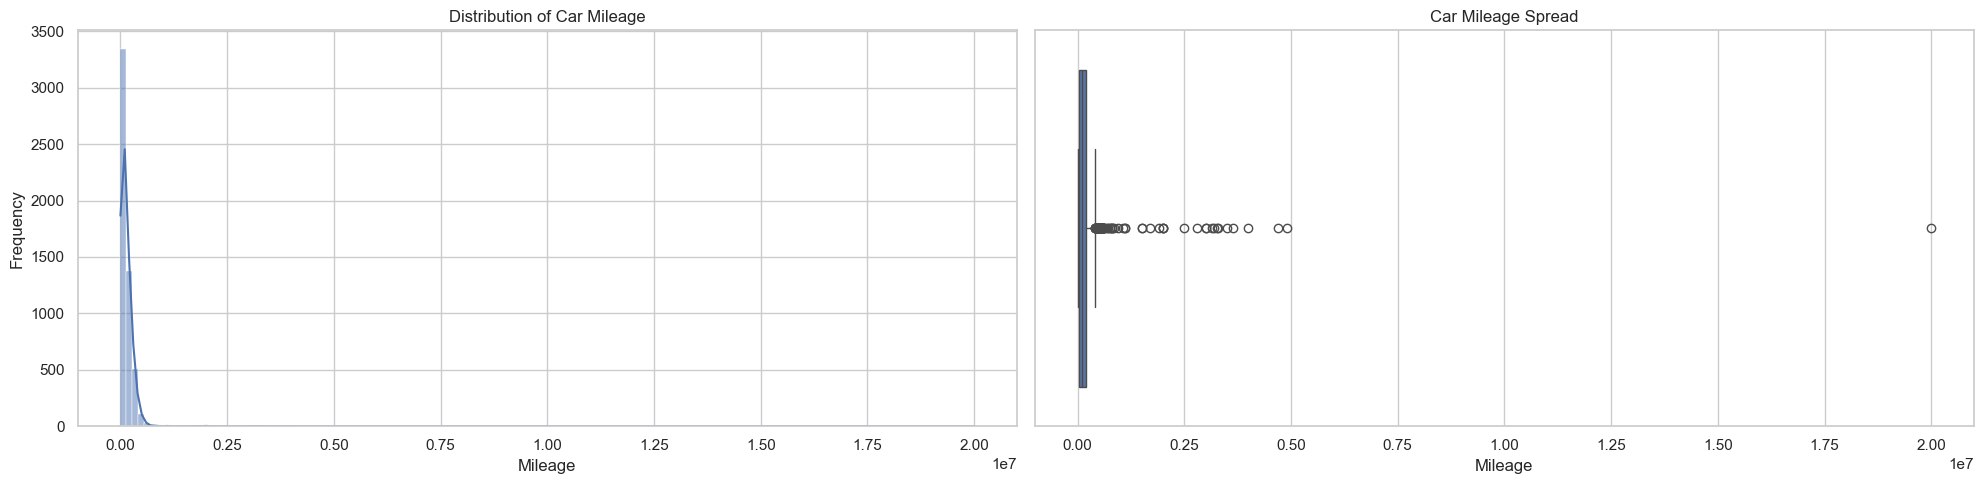

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Mileage'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Mileage')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Mileage'], ax=axes[1])
axes[1].set_title('Car Mileage Spread')
axes[1].set_xlabel('Mileage')

plt.tight_layout()
plt.show()

In [98]:
highest = df.sort_values(by='Mileage', ascending=False)[
    ['Year','Make','Mileage','Price']
].head(20).reset_index(drop=True)

lowest = df.sort_values(by='Mileage', ascending=True)[
    ['Year','Make','Mileage','Price']
].head(20).reset_index(drop=True)

separator = pd.DataFrame({' ': ['|']*20})

side_by_side = pd.concat(
    [highest, separator, lowest], 
    axis=1, 
    keys=['Highest Mileage', ' | ', 'Lowest Mileage']
)

side_by_side

Highest Mileage                               |  Lowest Mileage            \
              Year        Make   Mileage  Price               Year      Make   
0             2009   Chevrolet  20000000   9000   |           2005     Honda   
1             2010      Toyota   4900000      0   |           2015     Isuzu   
2             2012   Chevrolet   4691232      0   |           2020  Cadillac   
3             2006      Toyota   4000000      0   |           2021  Cadillac   
4             2013      Toyota   3640000  30000   |           2021      Jeep   
5             2004   Chevrolet   3500000  10000   |           2009     Honda   
6             2008   Chevrolet   3300000  27000   |           2021     Lexus   
7             2010        Ford   3275230      0   |           2016     Honda   
8             2007   Chevrolet   3187031      0   |           2014       GMC   
9             2008      Nissan   3150000  20000   |           2000  Mercedes   
10            2010        Ford   3000000  17000   |           2019    Toyota   
11            2009     Porsche   3000000      0   |           2003    Nissan   
12            2006      Toyota   2800000  35000   |           2016    Toyota   
13            2005        Ford   2500000   9000   |           2020   Renault   
14            2009  Land Rover   2013000  35000   |           2020   Hyundai   
15            2014         Kia   2002500  42000   |           2016      Jeep   
16            2007   Chevrolet   2000000   5000   |           2017    Suzuki   
17            2008        Ford   1910000      0   |           2008     Honda   
18            2014       Mazda   1700000      0   |           2016    Toyota   
19            2014     Hyundai   1500000      0   |           2016       Kia   

                    
   Mileage   Price  
0      100   20000  
1      100       0  
2      100  159000  
3      100  179000  
4      100       0  
5      100       0  
6      100       0  
7      100       0  
8      100       0  
9      100   15000  
10     100       0  
11     100       0  
12     100   32000  
13     100       0  
14     100   72910  
15     100       0  
16     100       0  
17     100       0  
18     100       0  
19     100   77000

Terdapat extreme outlier pada kolom `Mileage` yang pastinya akan berpengaruh dengan proses pelatihan model. maka dari itu outlier pada kolom `Mileage` akan dihapus berdasarkan domain Knowledge. Saya akan mengambil yang mileage nya dibawah 433.000 berdasarkan domain knowledge dan bersumber langsung dari website `syarah.com` maka diputuskan untuk menghapus kendaraan yang memiliki `Mileage` diatas 500 Ribu

Sumber :

https://syarah.com/en

https://www.dubizzle.sa/en/

https://ksa.carswitch.com/en/saudi/used-cars/search

In [99]:
df = df[df['Mileage'] <= 433000]
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0,13
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000,11
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,11
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0,6
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000,7
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000,8
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0,6
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000,10
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000,10


#### Mengetahui distribusi kolom `Mileage` setelah handling Outlier

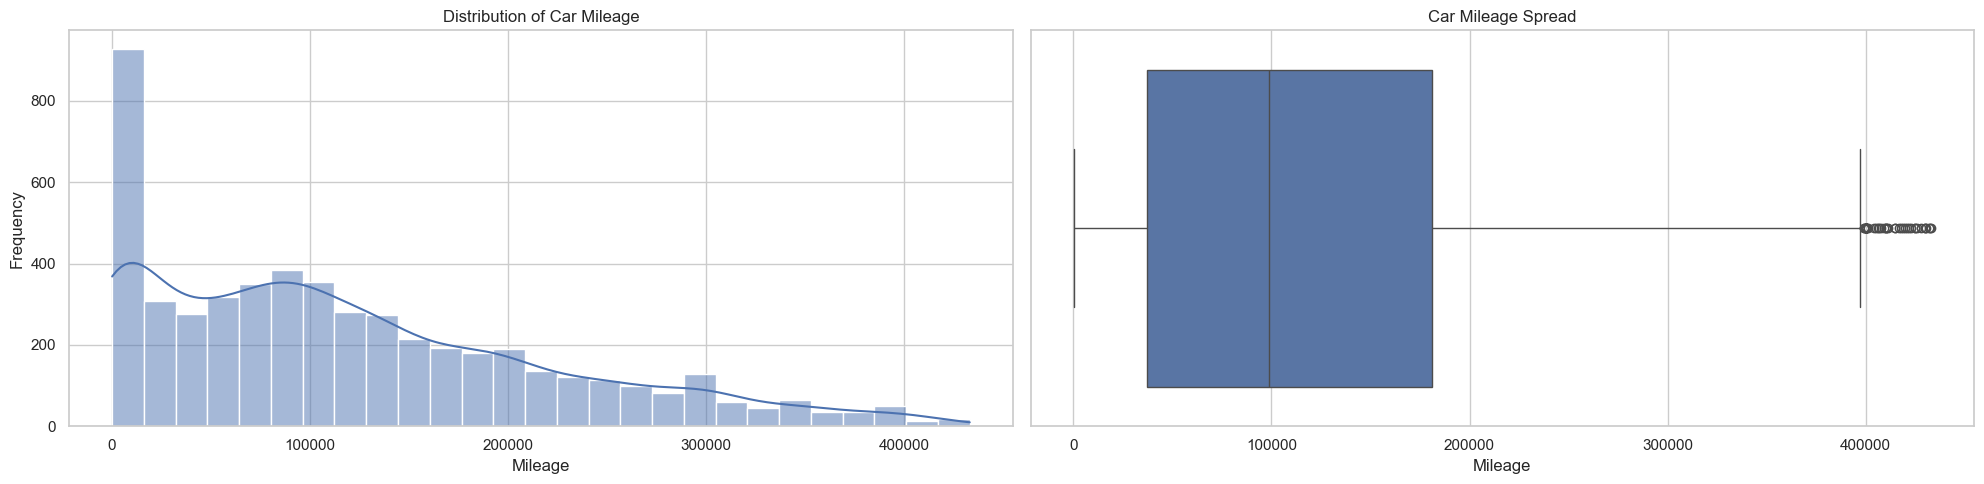

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Mileage'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Mileage')
axes[0].set_xlabel('Mileage')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Mileage'], ax=axes[1])
axes[1].set_title('Car Mileage Spread')
axes[1].set_xlabel('Mileage')

plt.tight_layout()
plt.show()

___

### Feature Engineering : `Mileage Per Year`

Untuk meningkatkan representativitas fitur terhadap target, dilakukan feature engineering dengan membentuk variabel Mileage_Per_Year. Kolom Mileage_Per_Year mengukur intensitas penggunaan kendaraan yang berpotensi memengaruhi kondisi dan harga jual

In [101]:
df['Mileage_Per_Year'] = df['Mileage'] / df['Car_Age']
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0,13,32384.615385
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000,11,12727.272727
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,11,20000.000000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0,6,8166.666667
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000,7,3571.428571
...,...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000,8,9849.250000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0,6,9666.666667
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000,10,4800.000000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000,10,8100.000000


In [102]:
df.sort_values('Mileage_Per_Year', ascending=False).head(10)

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year
2006,Furniture,Riyadh,Toyota,Automatic,Saudi,Semi Full,2017,2.7,400000,60000,9,44444.444444
2274,Hilux,Dammam,Toyota,Manual,Saudi,Semi Full,2017,2.7,384000,66000,9,42666.666667
3276,Camry,Dammam,Toyota,Automatic,Saudi,Standard,2017,2.5,380000,43000,9,42222.222222
2840,Camry,Dammam,Toyota,Automatic,Saudi,Standard,2017,2.5,362000,38000,9,40222.222222
1161,Dyna,Jeddah,Isuzu,Manual,Saudi,Standard,2016,3.0,400000,0,10,40000.000000
4036,Hilux,Riyadh,Toyota,Manual,Gulf Arabic,Full,2016,2.7,388000,55000,10,38800.000000
4491,FJ,Riyadh,Toyota,Automatic,Saudi,Semi Full,2016,4.0,381000,88000,10,38100.000000
3755,X-Trail,Riyadh,Nissan,Automatic,Saudi,Semi Full,2017,2.5,331612,46000,9,36845.777778
1811,H1,Jeddah,Hyundai,Automatic,Saudi,Standard,2015,4.0,400000,43000,11,36363.636364
4125,Camry,Dammam,Toyota,Automatic,Saudi,Standard,2017,2.5,327000,46000,9,36333.333333


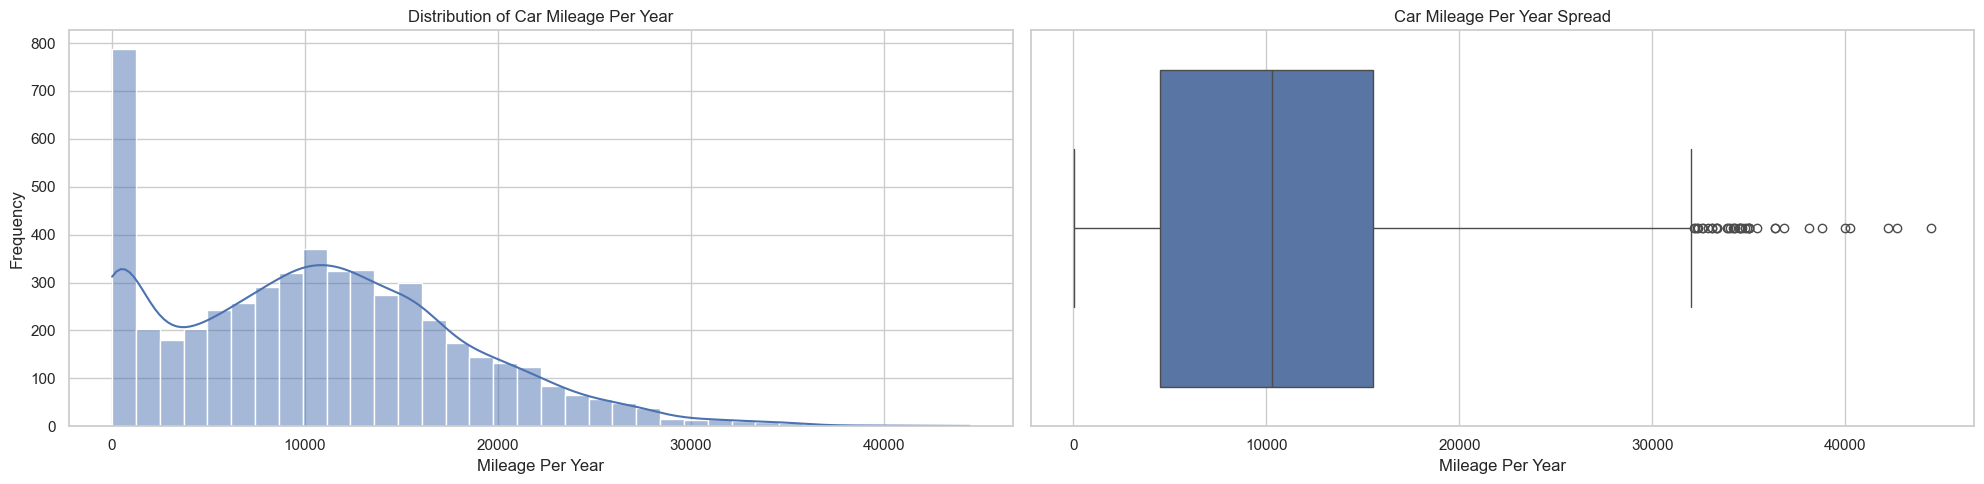

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Mileage_Per_Year'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Mileage Per Year')
axes[0].set_xlabel('Mileage Per Year')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Mileage_Per_Year'], ax=axes[1])
axes[1].set_title('Car Mileage Per Year Spread')
axes[1].set_xlabel('Mileage Per Year')

plt.tight_layout()
plt.show()

In [104]:
df['Mileage_Per_Year'].describe()

count     5245.000000
mean     10595.664616
std       7575.019349
min          3.846154
25%       4500.000000
50%      10308.625000
75%      15500.000000
max      44444.444444
Name: Mileage_Per_Year, dtype: float64

___

### Mengetahui distribusi kolom `Price`

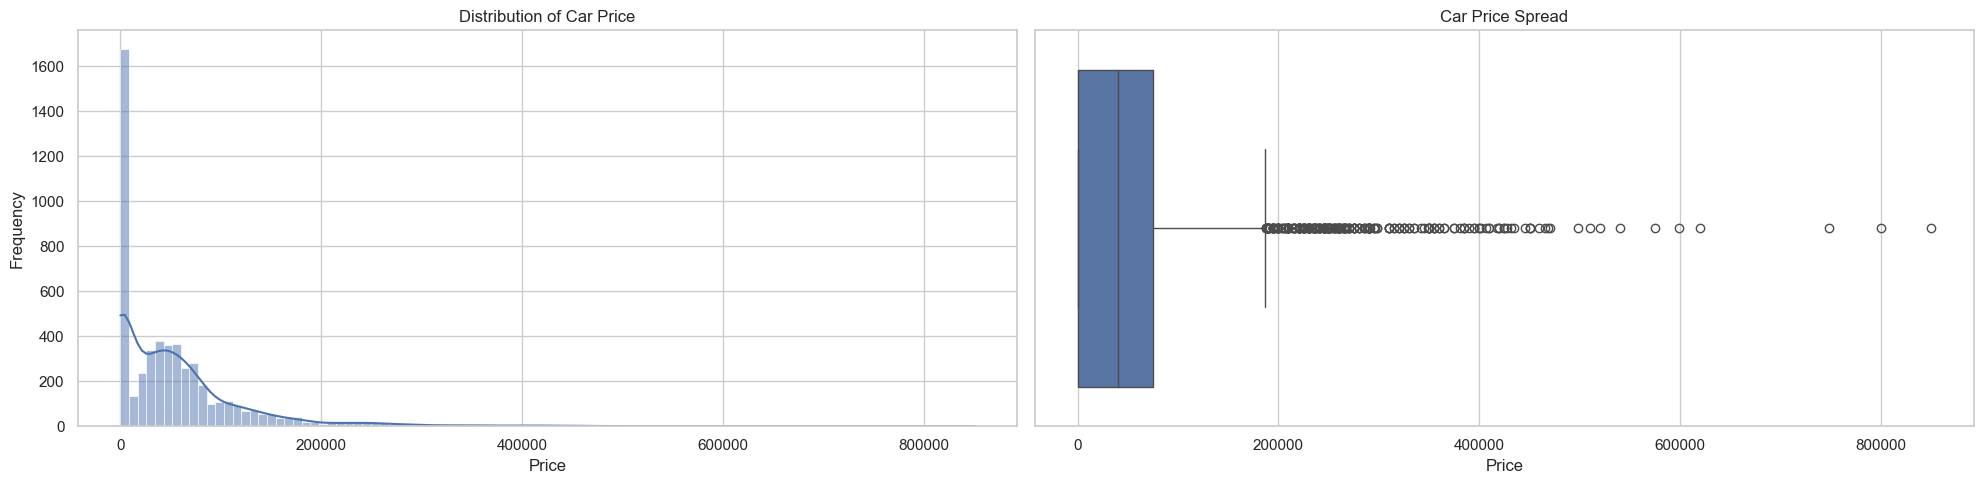

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Price'], ax=axes[1])
axes[1].set_title('Car Price Spread')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

Outlier pada kolom `Price` di asumsikan sebagai mobil mewah. Sedangkan Mobil dengan harga **0** dan **1** akan di drop karena itu akan mempengaruhi pola Machine Learning dalam melakukan training ke data.

In [106]:
df['Price'].describe()

count      5245.000000
mean      55239.808008
std       70728.800897
min           0.000000
25%           0.000000
50%       40000.000000
75%       75000.000000
max      850000.000000
Name: Price, dtype: float64

In [107]:
df[df['Price'] < 20000]

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0,13,32384.615385
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0,6,8166.666667
14,Hilux,Yanbu,Toyota,Automatic,Saudi,Full,2014,2.7,209,0,12,17.416667
20,Sunny,Riyadh,Nissan,Manual,Saudi,Standard,2011,1.4,290,7000,15,19.333333
22,Land Cruiser,Hail,Toyota,Automatic,Gulf Arabic,Full,2013,4.6,250,0,13,19.230769
...,...,...,...,...,...,...,...,...,...,...,...,...
5609,Land Cruiser 70,Taef,Toyota,Manual,Saudi,Full,2020,4.0,45000,2450,6,7500.000000
5614,Victoria,Makkah,Ford,Automatic,Saudi,Standard,2010,4.6,345000,0,16,21562.500000
5617,Yukon,Jubail,GMC,Automatic,Saudi,Semi Full,2006,5.3,300,0,20,15.000000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0,6,9666.666667


In [108]:
df = df[(df['Price'] > 1)&(df['Price'] < 182500)]
df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,11,20000.000000
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000,7,3571.428571
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,85000,14,13500.000000
7,Sonata,Riyadh,Hyundai,Automatic,Saudi,Full,2016,2.4,155,48000,10,15.500000
8,Avalon,Riyadh,Toyota,Automatic,Saudi,Standard,2016,3.5,110864,81500,10,11086.400000
...,...,...,...,...,...,...,...,...,...,...,...,...
5616,CX9,Qassim,Mazda,Automatic,Saudi,Full,2020,2.0,9500,132000,6,1583.333333
5618,Suburban,Riyadh,GMC,Automatic,Saudi,Full,2006,5.3,86000,50000,20,4300.000000
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000,8,9849.250000
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000,10,4800.000000


#### Mengetahui distribusi kolom `Price` setelah handling Outlier

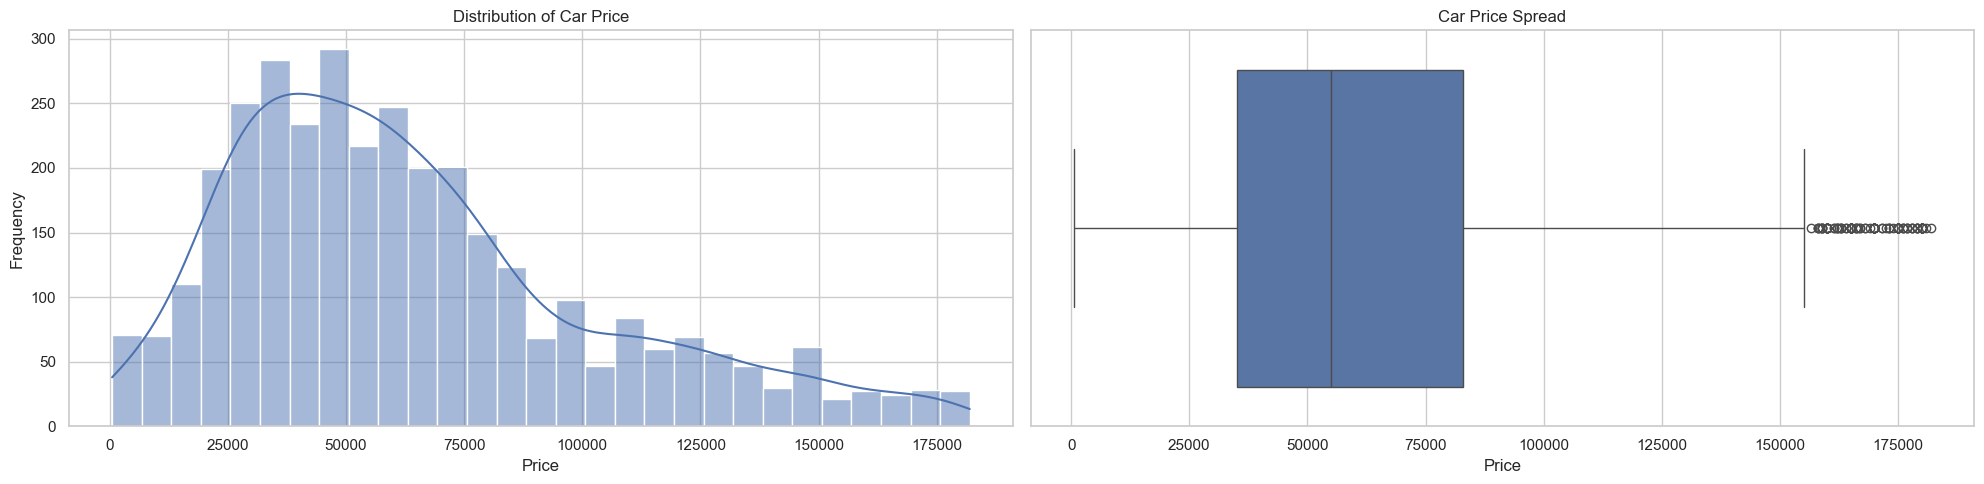

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))

# Histogram
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Car Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df['Price'], ax=axes[1])
axes[1].set_title('Car Price Spread')
axes[1].set_xlabel('Price')

plt.tight_layout()
plt.show()

___

## Melihat Distribusi Semua Kolom `Numerikal` Setelah Handling Outliers

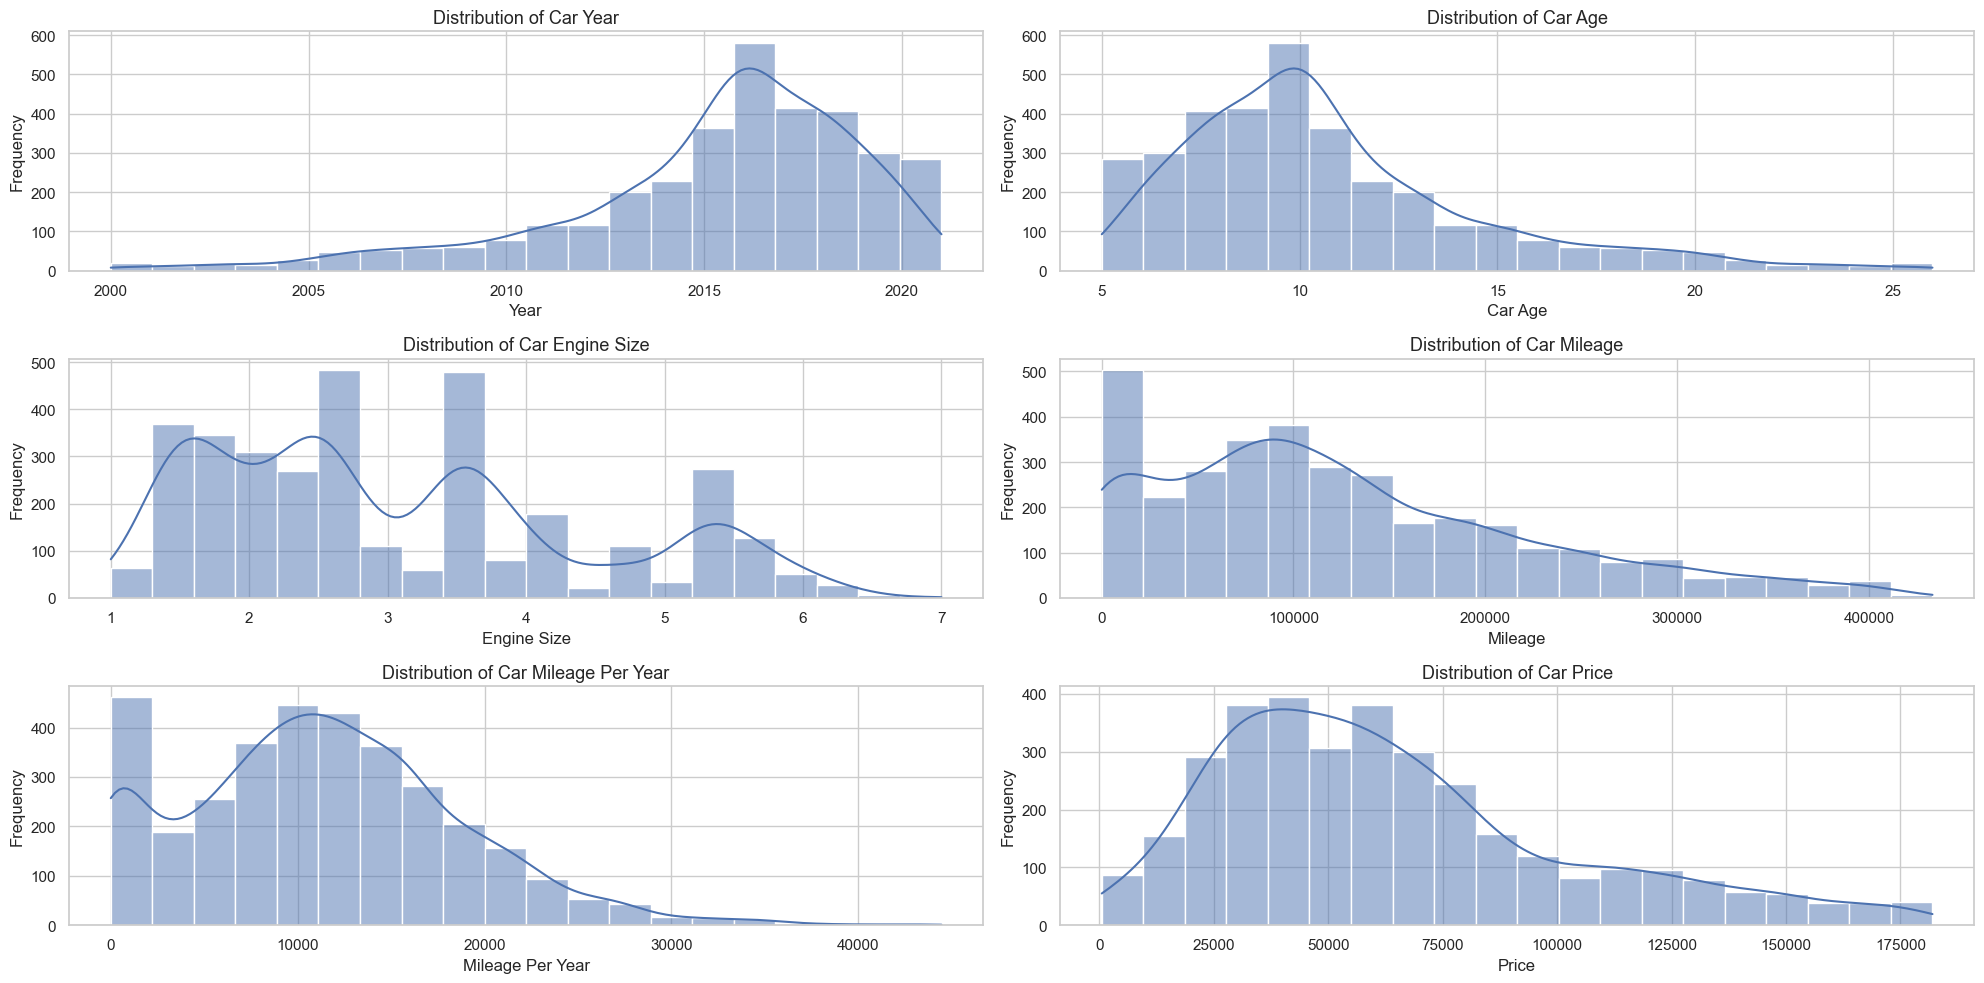

In [110]:
plt.figure(figsize=(20, 10))
sns.set(style='whitegrid')

# Plot distribusi untuk 'Year'
plt.subplot(321)
sns.histplot(df['Year'], bins=20, kde=True)
plt.title('Distribution of Car Year', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Frequency')

# Plot distribusi untuk 'Price'
plt.subplot(322)
sns.histplot(df['Car_Age'], bins=20, kde=True)
plt.title('Distribution of Car Age', fontsize=13)
plt.xlabel('Car Age')
plt.ylabel('Frequency')

# Plot distribusi untuk 'Engine_Size'
plt.subplot(323)
sns.histplot(df['Engine_Size'], bins=20, kde=True)
plt.title('Distribution of Car Engine Size', fontsize=13)
plt.xlabel('Engine Size')
plt.ylabel('Frequency')

# Plot distribusi untuk 'Mileage'
plt.subplot(324)
sns.histplot(df['Mileage'], bins=20, kde=True)
plt.title('Distribution of Car Mileage', fontsize=13)
plt.xlabel('Mileage')
plt.ylabel('Frequency')

# Plot distribusi untuk 'Price'
plt.subplot(325)
sns.histplot(df['Mileage_Per_Year'], bins=20, kde=True)
plt.title('Distribution of Car Mileage Per Year', fontsize=13)
plt.xlabel('Mileage Per Year')
plt.ylabel('Frequency')

# Plot distribusi untuk 'Price'
plt.subplot(326)
sns.histplot(df['Price'], bins=20, kde=True)
plt.title('Distribution of Car Price', fontsize=13)
plt.xlabel('Price')
plt.ylabel('Frequency')

# Menata ulang layout agar lebih rapi
plt.tight_layout()
plt.show()

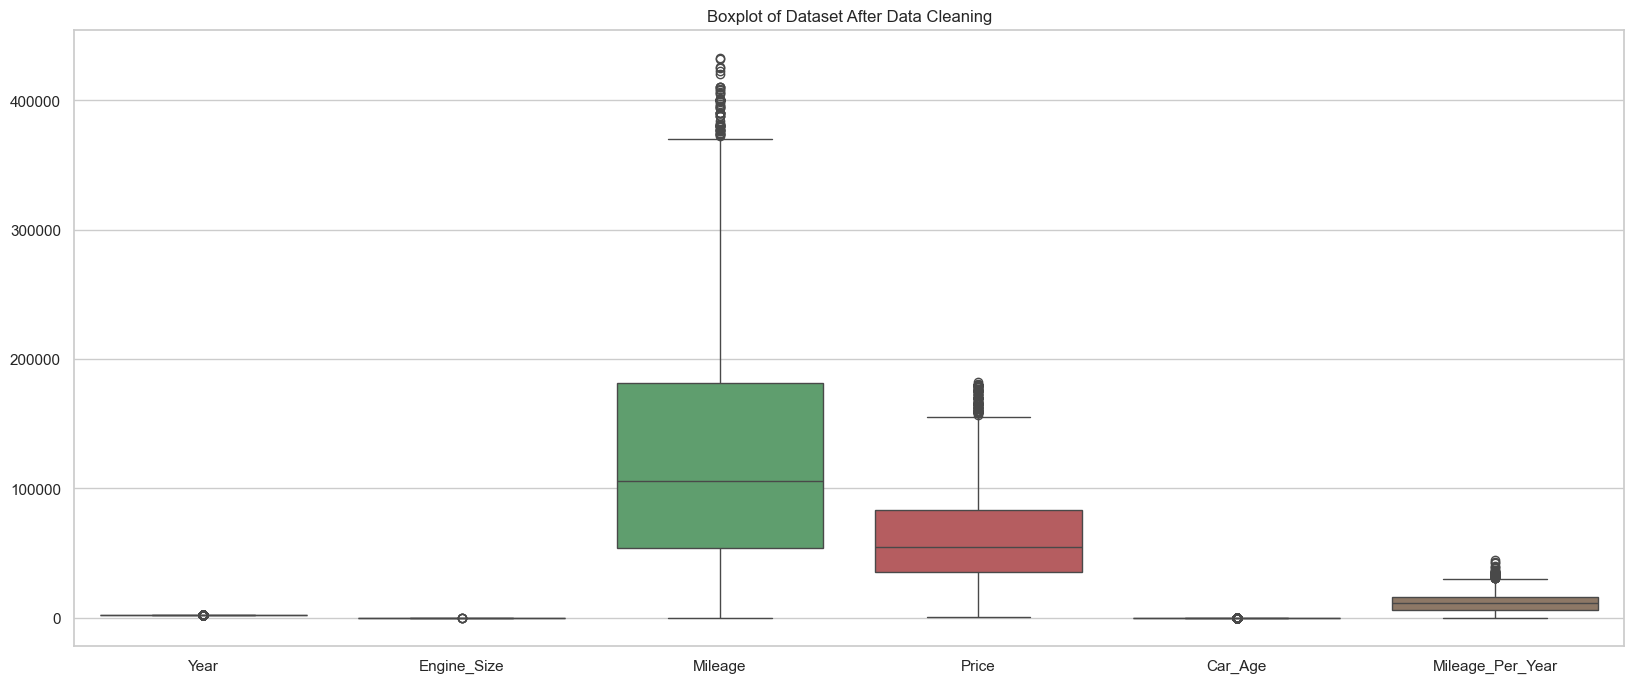

In [111]:
plt.figure(figsize=(20,8))
sns.boxplot(data=df)
plt.title('Boxplot of Dataset After Data Cleaning')
plt.show()

In [112]:
df.corr(numeric_only=True)

,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year
Year,1.000000,-0.348388,-0.482035,0.358221,-1.000000,-0.131531
Engine_Size,-0.348388,1.000000,0.220876,0.330179,0.348388,0.101738
Mileage,-0.482035,0.220876,1.000000,-0.245137,0.482035,0.889359
Price,0.358221,0.330179,-0.245137,1.000000,-0.358221,-0.142142
Car_Age,-1.000000,0.348388,0.482035,-0.358221,1.000000,0.131531
Mileage_Per_Year,-0.131531,0.101738,0.889359,-0.142142,0.131531,1.000000


___

### Mengetahui distribusi kolom `Kategorikal`

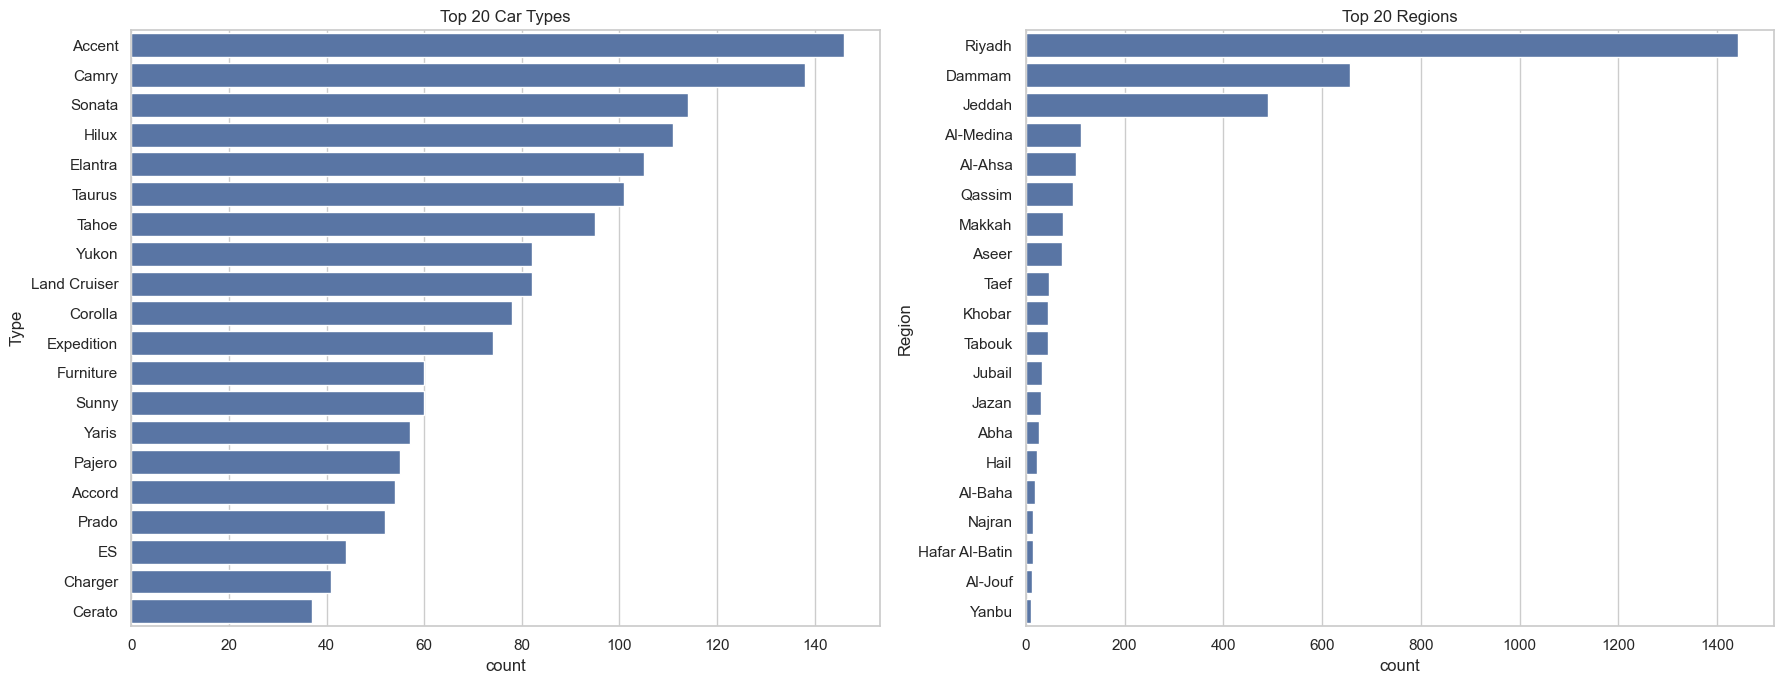

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(18,7))

# Type
top_type = df['Type'].value_counts().head(20).index
sns.countplot(
    y='Type',
    data=df[df['Type'].isin(top_type)],
    order=top_type,
    ax=axes[0]
)
axes[0].set_title('Top 20 Car Types')

# Region
top_region = df['Region'].value_counts().head(20).index
sns.countplot(
    y='Region',
    data=df[df['Region'].isin(top_region)],
    order=top_region,
    ax=axes[1]
)
axes[1].set_title('Top 20 Regions')

plt.tight_layout()
plt.show()

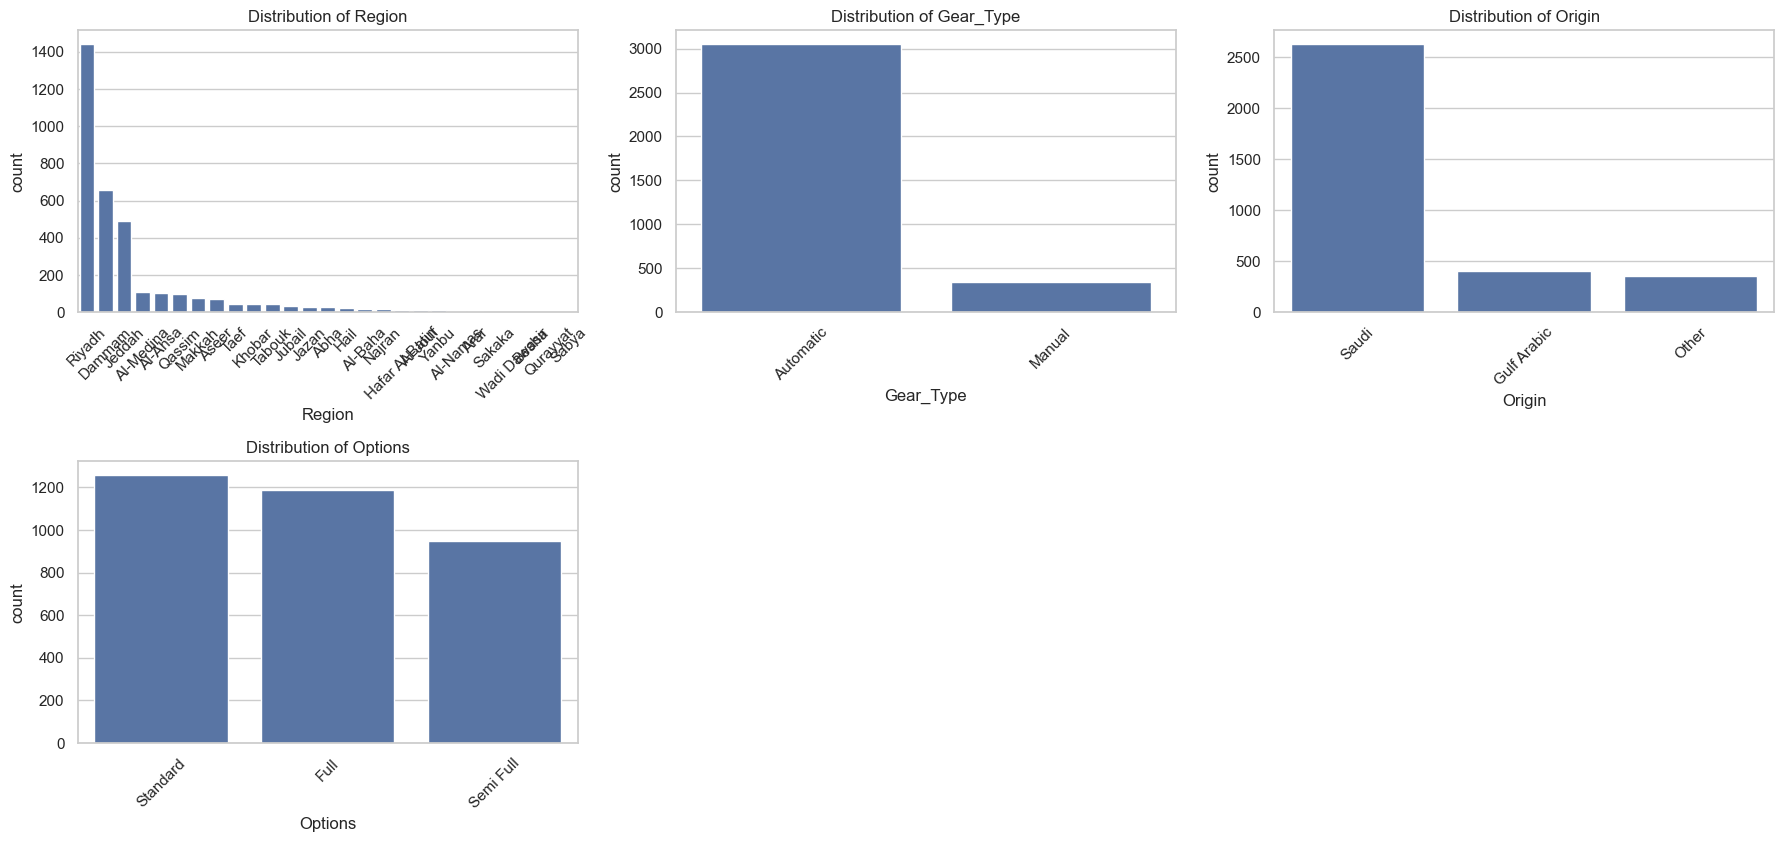

In [114]:
categorical_cols = ['Region','Gear_Type','Origin','Options']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hapus subplot kosong kalau ada
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

___

## **Data Splitting**

In [115]:
# feature
X=df.drop('Price',axis=1)

y=df['Price']

In [116]:
## split data
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

___

## **Preprocessing**

Dalam proses Preprocessing, dilakukan preprocessing menggunakan ColumnTransformer, meliputi:

- One Hot Encoding untuk variabel kategorikal tertentu
- Binary Encoding untuk fitur dengan banyak kategori
- Robust Scaling untuk menangani outlier pada fitur numerik
- Pipeline digunakan untuk memastikan proses transformasi dan modeling berjalan konsisten

In [ ]:
# Define algoritma yang digunakan
lr = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(random_state=42)

# Kandidat algoritma
models = [lr, knn, dt, rf, xgb]

score_rmse = []
nilai_mean_rmse = []
nilai_std_rmse = []

score_mae = []
nilai_mean_mae = []
nilai_std_mae = []

score_mape = []
nilai_mean_mape = []
nilai_std_mape = []

In [118]:
#define transformer
preprocessor=ColumnTransformer(transformers =[
    ('OHEencoder', OneHotEncoder(drop= 'first'), ['Gear_Type','Origin', 'Options']),
    ('BinaryEncoder',BinaryEncoder(),['Type','Region','Make']),
    ('Scalling', RobustScaler(), X.select_dtypes('number').columns)
],remainder= 'passthrough')

In [ ]:
# Mencari algoritma terbaik berdasarkan tiap metrics
for i in models:
    
    crossval = KFold(n_splits=5, shuffle=True, random_state=1)

    estimator = Pipeline([
        ('preprocessing', preprocessor),
        ('model', i)
    ])

    # RMSE
    model_cv_rmse = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_root_mean_squared_error', 
        error_score='raise'
        )

    print(model_cv_rmse, i)

    score_rmse.append(model_cv_rmse)
    nilai_mean_rmse.append(model_cv_rmse.mean())
    nilai_std_rmse.append(model_cv_rmse.std())

    # MAE
    model_cv_mae = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_mean_absolute_error', 
        error_score='raise'
        )

    print(model_cv_mae, i)

    score_mae.append(model_cv_mae)
    nilai_mean_mae.append(model_cv_mae.mean())
    nilai_std_mae.append(model_cv_mae.std())

    # MAPE
    model_cv_mape = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_mean_absolute_percentage_error', 
        error_score='raise'
        )

    print(model_cv_mape, i)

    score_mape.append(model_cv_mape)
    nilai_mean_mape.append(model_cv_mape.mean())
    nilai_std_mape.append(model_cv_mape.std())

[-26235.49214867 -27365.51268596 -28822.1837843  -25299.78417242
 -28025.89754569] LinearRegression()
[-19285.75471775 -19606.2700482  -21090.30422616 -18189.71052875
 -20216.25350467] LinearRegression()
[-1.4225399  -0.9766436  -1.68788844 -0.99048504 -0.96577794] LinearRegression()
[-22088.22640556 -23085.6073772  -23024.12161874 -20960.71071623
 -21606.51611534] KNeighborsRegressor()
[-14964.79558824 -16127.89060773 -15067.54069982 -13670.66593002
 -14301.05782689] KNeighborsRegressor()
[-1.16441128 -0.90840673 -1.45197703 -0.84631871 -0.74361446] KNeighborsRegressor()
[-29700.52589834 -30089.27002402 -28556.60864287 -28094.64218578
 -31640.67889522] DecisionTreeRegressor(random_state=42)
[-19407.38051471 -18583.58747698 -18518.20257827 -17437.32228361
 -19314.72928177] DecisionTreeRegressor(random_state=42)
[-1.22244348 -0.85144619 -1.49238772 -1.10413363 -0.90197461] DecisionTreeRegressor(random_state=42)
[-19677.21695201 -21663.54849827 -23112.99986686 -19053.32583007
 -21554.566

In [120]:
# Evaluasi hasil dari 5 kandidat algoritma yang digunakan
pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor', 'DecisionTree Regressor', 'RandomForest Regressor', 'XGBoost Regressor'],
    'Mean_RMSE': nilai_mean_rmse,
    'Std_RMSE': nilai_std_rmse,
    'Mean_MAE': nilai_mean_mae,
    'Std_MAE': nilai_std_mae,
    'Mean_MAPE': nilai_mean_mape,
    'Std_MAPE': nilai_std_mape
})

,Model,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_MAPE,Std_MAPE
0,Linear Regression,-27149.774067,1254.548827,-19677.658605,965.228116,-1.208667,0.295238
1,KNN Regressor,-22153.036447,818.902116,-14826.390131,822.543083,-1.022946,0.255508
2,DecisionTree Regressor,-29616.345129,1246.378179,-18652.244427,708.213739,-1.114477,0.231915
3,RandomForest Regressor,-21012.331536,1466.365853,-13377.646127,842.835410,-1.035165,0.301852
4,XGBoost Regressor,-20930.367188,849.831886,-13549.928125,333.090821,-1.004757,0.291498


___

## **MODEL BENCHMARKING**

In [121]:
# Benchmark 2 model terbaik
models = {
    'XGB': XGBRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split=10, min_samples_leaf=5, max_features='sqrt', random_state=42)
}

score_rmse = []
score_mae = []
score_mape = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', models[i])
        ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    score_mae.append(mean_absolute_error(y_test, y_pred))
    score_mape.append(mean_absolute_percentage_error(y_test, y_pred))

score_before_tuning = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape}, index=models.keys())
score_before_tuning

,RMSE,MAE,MAPE
XGB,20902.533435,13252.745117,1.286779
RandomForest,23336.266436,16027.697888,1.481564


Model yang digunakan dalam penelitian ini adalah XGBoost Regressor, yang dikenal memiliki performa tinggi dalam menangani data tabular serta mampu menangkap hubungan non-linear antar variabel.

___

## **Hyperparameter Tuning**

In [122]:
param_grid_xgb = {
    'model__max_depth': [3],
    'model__learning_rate': [0.01, 0.02],
    'model__n_estimators': [300],
    'model__subsample': [0.7],
    'model__colsample_bytree': [0.7],
    'model__gamma': range(5, 11),
    'model__reg_alpha': [8, 10],
    'model__reg_lambda': [8, 10, 20]
}

In [123]:
# Benchmark model dengan hyperparameter tuning
xgb = XGBRegressor(random_state=42)

# Membuat algorithm chains
estimator_xgb = Pipeline([
        ('preprocessing', preprocessor),
        ('model', xgb)
        ])

crossval = KFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter tuning
random_xgb = RandomizedSearchCV(
    estimator_xgb, 
    param_distributions = param_grid_xgb,
    n_iter = 100,
    cv = crossval, 
    scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 
               'neg_mean_absolute_percentage_error'], 
    n_jobs = -1,
    refit = 'neg_root_mean_squared_error', # Hanya bisa memilih salah stau metric untuk optimisasi
    random_state = 42  
)

In [124]:
# Fitting data training untuk mencari parameter terbaik
random_xgb.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7], 'model__gamma': range(5, 11), 'model__learning_rate': [0.01, 0.02], 'model__max_depth': [3], ...}"
,n_iter,100
,scoring,"['neg_root_mean_squared_error', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [125]:
random_xgb.best_params_

{'model__subsample': 0.7,
 'model__reg_lambda': 8,
 'model__reg_alpha': 8,
 'model__n_estimators': 300,
 'model__max_depth': 3,
 'model__learning_rate': 0.02,
 'model__gamma': 5,
 'model__colsample_bytree': 0.7}

In [126]:
best_model_grid = random_xgb.best_estimator_

In [127]:
# Melihat hasil tuning dalam bentuk dataframe. Diurutkan berdasarkan RMSE, MAE & MAPE
pd.DataFrame(random_xgb.cv_results_).sort_values(by=['rank_test_neg_root_mean_squared_error', 'rank_test_neg_mean_absolute_error', 'rank_test_neg_mean_absolute_percentage_error']).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__reg_lambda,param_model__reg_alpha,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,...,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_neg_mean_absolute_percentage_error,split1_test_neg_mean_absolute_percentage_error,split2_test_neg_mean_absolute_percentage_error,split3_test_neg_mean_absolute_percentage_error,split4_test_neg_mean_absolute_percentage_error,mean_test_neg_mean_absolute_percentage_error,std_test_neg_mean_absolute_percentage_error,rank_test_neg_mean_absolute_percentage_error
6,0.250869,0.020127,0.022154,0.004659,0.7,8,8,300,3,0.02,...,674.952735,1,-1.175433,-0.793767,-1.099337,-1.105793,-1.388472,-1.11256,0.190751,1
18,0.267093,0.029455,0.019956,0.001007,0.7,8,8,300,3,0.02,...,674.952735,1,-1.175433,-0.793767,-1.099337,-1.105793,-1.388472,-1.11256,0.190751,1
30,0.230474,0.014616,0.019579,0.001750,0.7,8,8,300,3,0.02,...,674.952735,1,-1.175433,-0.793767,-1.099337,-1.105793,-1.388472,-1.11256,0.190751,1
42,0.268171,0.021288,0.019215,0.001274,0.7,8,8,300,3,0.02,...,674.952735,1,-1.175433,-0.793767,-1.099337,-1.105793,-1.388472,-1.11256,0.190751,1
54,0.304957,0.029422,0.022964,0.004149,0.7,8,8,300,3,0.02,...,674.952735,1,-1.175433,-0.793767,-1.099337,-1.105793,-1.388472,-1.11256,0.190751,1


In [128]:
best_model_grid.score(X_train, y_train)
best_model_grid.score(X_test, y_test)

0.6184561252593994

In [129]:
# Cek skor dan params terbaik
print('XGBoost')
print('Best_score:', random_xgb.best_score_)
print('Best_params:', random_xgb.best_params_)

XGBoost
Best_score: -23193.557421875
Best_params: {'model__subsample': 0.7, 'model__reg_lambda': 8, 'model__reg_alpha': 8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__gamma': 5, 'model__colsample_bytree': 0.7}


**Predict to Test Set with the Tuned Model**

Melakukan prediksi pada test set dengan menggunakan model XGBoost dan hyperparameter terpilih.

In [130]:
# Model XGBoost
model = {'XGB': XGBRegressor(random_state=42)}

# Define model terhadap estimator terbaik
xgb_tuning = random_xgb.best_estimator_

# Fitting model
xgb_tuning.fit(X_train, y_train)

# Predict test set
y_pred_xgb_tuning = xgb_tuning.predict(X_test)

# Simpan nilai metrics RMSE, MAE & MAPE setelah tuning
rmse_xgb_tuning = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuning))
mae_xgb_tuning = mean_absolute_error(y_test, y_pred_xgb_tuning)
mape_xgb_tuning = mean_absolute_percentage_error(y_test, y_pred_xgb_tuning)

score_after_tuning = pd.DataFrame({'RMSE': rmse_xgb_tuning, 'MAE': mae_xgb_tuning, 'MAPE': mape_xgb_tuning}, index=model.keys())
score_after_tuning

,RMSE,MAE,MAPE
XGB,23327.558295,15877.500977,1.47453


___

## **Performance Comparison**

Perbandingan performa model XGBoost sebelum dan sesudah dilakukan hyperparameter tuning.

In [131]:
# Sebelum hyperparameter tuning
pd.DataFrame(score_before_tuning.loc['XGB']).T

,RMSE,MAE,MAPE
XGB,20902.533435,13252.745117,1.286779


In [132]:
# Setelah hyperparameter tuning
score_after_tuning

,RMSE,MAE,MAPE
XGB,23327.558295,15877.500977,1.47453


In [133]:
# Train
y_train_pred = best_model_grid.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Test
y_test_pred = best_model_grid.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('RMSE Train:', rmse_train)
print('RMSE Test:', rmse_test)

gap = (rmse_test - rmse_train) / rmse_train * 100
print('Gap %:', gap)

RMSE Train: 21939.838467955957
RMSE Test: 23327.558294858038
Gap %: 6.325114147621931


Model mengalami peningkatan performa (nilai RMSE, MAE & MAPE berkurang) dengan dilakukannya hyperparameter tuning, walaupun hanya sedikit.
- RMSE, MAE & MAPE sebelum tuning: 20902.53, 13252.74, 1.28
- RMSE, MAE & MAPE setelah tuning: 23327.55, 15877.50, 1.47

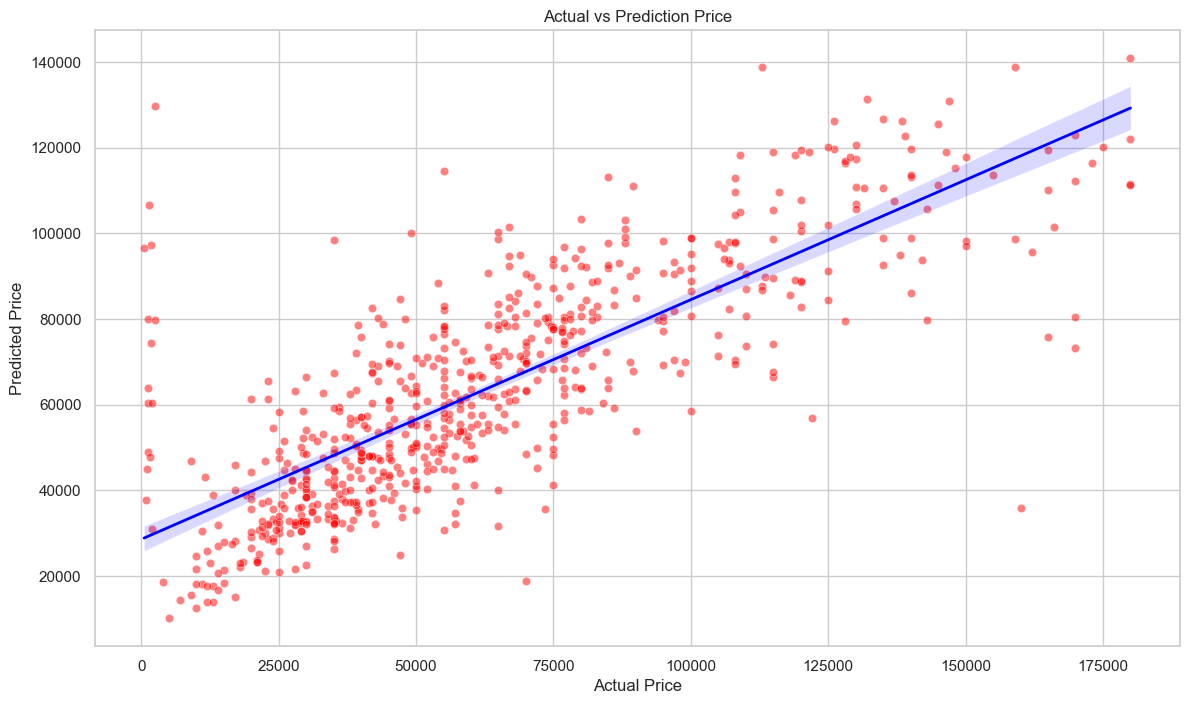

In [134]:
plt.figure(figsize=(14, 8))

sns.scatterplot(x=y_test, y=y_pred_xgb_tuning, color='red', alpha=0.5)
sns.regplot(x=y_test, y=y_pred_xgb_tuning, scatter=False, color='blue', line_kws={'linewidth': 2})
plt.title('Actual vs Prediction Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Menampilkan plot

plt.show()

___

## **Feature Importances**

Untuk dapat mengetahui sebenarnya fitur apa saja yang sangat memengaruhi target (price), kita dapat mengeceknya melalui function feature_importances_.

In [135]:
xgb_model = best_model_grid.named_steps['model']
feature_names = best_model_grid.named_steps['preprocessing'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Value': xgb_model.feature_importances_
}).sort_values(by='Value', ascending=False)

importance_df.head(10)

,Feature,Value
26,Scalling__Engine_Size,0.113735
28,Scalling__Car_Age,0.100468
25,Scalling__Year,0.087033
4,OHEencoder__Options_Standard,0.065429
2,OHEencoder__Origin_Saudi,0.060725
24,BinaryEncoder__Make_5,0.055583
27,Scalling__Mileage,0.051681
13,BinaryEncoder__Type_8,0.041279
3,OHEencoder__Options_Semi Full,0.037630
29,Scalling__Mileage_Per_Year,0.036367


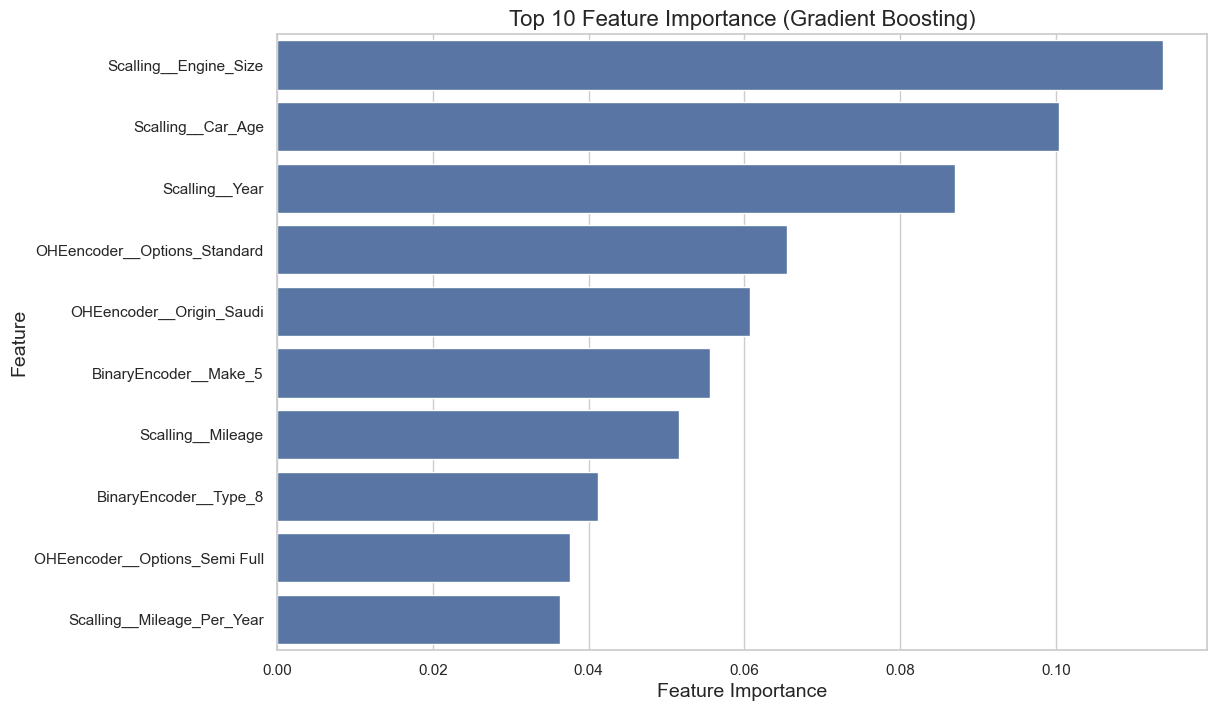

In [136]:
# Plot bar chart untuk Top 10 Fitur yang Paling Penting
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(10), x='Value', y='Feature')
plt.title('Top 10 Feature Importance (Gradient Boosting)', fontsize=16)
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.show()

___

## **Conclusion** 

Secara keseluruhan, model machine learning yang dikembangkan menggunakan XGBoost Regressor menunjukkan performa yang cukup baik dalam memprediksi nilai target. Model mampu menangkap pola utama dalam data dengan tingkat error yang relatif rendah, Hal ini ditunjukkan dari nilai evaluasi RMSE (Root Mean Squared Error) yang menampilkan error sebesar 6.32%. karena ada jarak antara data test dan data train yaitu RMSE Train : 21939.838467955957, RMSE Test : 23327.558294858038. Sehingga mengindikasikan bahwa rata-rata kesalahan prediksi model masih dalam batas yang dapat diterima.

Proses benchmarking juga memperlihatkan bahwa XGBoost merupakan algoritma dengan performa terbaik dibandingkan model lain yang diuji. Namun, hasil hyperparameter tuning menunjukkan bahwa peningkatan kompleksitas model tidak selalu menghasilkan performa yang lebih baik. Dalam studi ini, model baseline justru memberikan hasil evaluasi yang lebih optimal dibandingkan model hasil tuning.

Dari sisi diagnostik, ditemukan bahwa model masih memiliki keterbatasan dalam memprediksi nilai pada rentang yang tinggi, yang ditunjukkan oleh heteroskedasticity.Hal ini menunjukkan bahwa model belum sepenuhnya mampu menangkap pola kompleks pada rentang nilai ekstrem.

Dengan demikian, dapat disimpulkan bahwa model sudah cukup robust dan layak digunakan sebagai baseline. Namun, masih terdapat ruang untuk perbaikan, khususnya dalam meningkatkan akurasi prediksi pada nilai tinggi serta mengurangi variasi error.

___

## **Recomendation**

Berdasarkan hasil diatas, terdapat beberapa rekomendasi yang dapat dilakukan untuk pengembangan lebih lanjut adalah sebagai berikut:

**1. Model Improvement**
- Menerapkan transformasi pada variabel target, seperti log transformation, untuk mengurangi skewness dan mengatasi heteroskedasticity
- Mengeksplorasi algoritma lain yang lebih adaptif terhadap distribusi data kompleks, seperti LightGBM atau CatBoost
- Melakukan tuning hyperparameter dengan ruang pencarian yang lebih luas dan terarah

**2. Feature Engineering**
- Melakukan feature selection untuk mengurangi noise dan meningkatkan interpretabilitas model

**3. Error & Data Handling**
- Melakukan analisis lebih lanjut terhadap outlier, khususnya pada nilai target tinggi
- Menggunakan pendekatan robust modeling untuk mengurangi sensitivitas terhadap data ekstrem
- Mengevaluasi distribusi residual untuk memastikan asumsi model lebih terpenuhi

___

## Saving Model for Deployment

In [137]:
import pickle

In [139]:
best_model_grid = random_xgb.best_estimator_

best_model_grid.fit(X,y)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHEencoder', ...), ('BinaryEncoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [140]:
pickle.dump(best_model_grid,open('best_model.sav','wb'))

___